# Project Overview: RBA Payments Data Analysis

This notebook contains a comprehensive data analysis project focused on understanding the dynamics of RBA payments data. The project aims to extract meaningful insights from the provided datasets to support informed decision-making.

## Overall Goal

The primary goal of this project is to analyze RBA payments data to identify key trends, patterns, and anomalies that influence the Australian payments landscape. This analysis will help in understanding economic indicators, payment system efficiency, and potential areas for policy intervention or improvement.

## Objectives

To achieve the overall goal, the following specific objectives will be pursued:

*   **Data Cleaning and Preprocessing**: Ensure the RBA payments datasets are clean, consistent, and ready for analysis by handling missing values, outliers, and data type conversions.
*   **Exploratory Data Analysis (EDA)**: Conduct a thorough EDA to uncover initial insights, statistical summaries, and visual representations of the payments data, highlighting distributions, relationships, and potential areas of interest.
*   **Trend Identification**: Identify significant trends in various payment methods (e.g., cash, electronic transfers, cards) over specified periods, including seasonal variations and long-term growth or decline.
*   **Comparative Analysis**: Compare payment behaviors and volumes across different categories (e.g., consumer, business, government) to understand their respective contributions and changes.
*   **Anomaly Detection**: Pinpoint unusual or unexpected patterns in the payments data that might indicate economic shifts, market disruptions, or data quality issues.
*   **Reporting and Visualization**: Generate clear, concise, and visually appealing reports and dashboards that summarize findings and communicate actionable insights to stakeholders.

## Scope

This project will focus exclusively on the provided RBA payments data. The analysis will cover:

*   **Datasets**: Specifically, data pertaining to various payment instruments and transactions as supplied by the Reserve Bank of Australia.
*   **Timeframe**: The analysis will encompass the entire historical period available within the provided datasets. Specific date ranges will be determined upon initial data inspection.
*   **Geographical Focus**: The scope is limited to payment activities within Australia, reflecting the RBA's jurisdiction.
*   **Key Metrics**: Analysis will primarily revolve around transaction volumes, values, and the adoption rates of different payment types.

**Exclusions**: This project will not involve external economic data unless explicitly provided or deemed necessary for context during the analysis phase. Predictive modeling or forecasting will not be the primary focus, although insights gained may inform future forecasting efforts.

## 1. Import Libraries

This section imports all necessary libraries for data manipulation, analysis, and visualization throughout the project.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

RBA C01 Data: Credit and Charge Cards

The RBA C01 dataset, titled 'Credit and Charge Cards: Number of Accounts, Balances Outstanding, and Transactions', provides comprehensive statistics on credit and charge card activity in Australia. This data is crucial for understanding consumer spending habits, the prevalence of credit, and the volume and value of card-based transactions. Analysis of this dataset can reveal trends in credit usage, the shift towards electronic payments, and the overall health of the consumer credit market.

In [ ]:
#Download c01 data from RBA website.
url_c01 = 'https://www.rba.gov.au/statistics/tables/xls/c01hist.xlsx'
df_c01 = pd.read_excel(url_c01, sheet_name=0, skiprows=10)

print(f"df_c01 loaded with shape: {df_c01.shape}") #Skip the first 10 rows

df_c01 loaded with shape: (494, 62)


## 3. Selecting and Describing Key C01 Columns

We will now select the most relevant columns from the `df_c01` dataset for our analysis. These columns represent key metrics related to credit and charge card transactions.

In [ ]:
cols_to_select_c01 = [
    'Series ID', # This will be renamed to 'Date'
    'CCCCSTPNSA', # Credit_Purchases_Count
    'CCCCSTPVSA', # Credit_Purchases_Value
    'CCCCSTTNSA', # Total_Cards_Transactions_Count
    'CCCCSTTVSA'  # Total_Cards_Transactions_Value
]

df_c01_selected = df_c01[cols_to_select_c01].copy()
df_c01_selected = df_c01_selected.rename(columns={'Series ID': 'Date'})

print("Selected C01 columns and renamed 'Series ID' to 'Date'.")
display(df_c01_selected.head())

Selected C01 columns and renamed 'Series ID' to 'Date'.


,Date,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA
0,1985-01-31,NaN,403.111262,NaN,531.417509
1,1985-02-28,NaN,454.293099,NaN,566.998604
2,1985-03-31,NaN,519.588687,NaN,630.971364
3,1985-04-30,NaN,465.883915,NaN,547.236616
4,1985-05-31,NaN,594.553894,NaN,710.567407


In [ ]:
df_c01_selected['Date'] = pd.to_datetime(df_c01_selected['Date'])

print("Converted 'Date' column to datetime objects.")
display(df_c01_selected.head())

Converted 'Date' column to datetime objects.


,Date,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA
0,1985-01-31,NaN,403.111262,NaN,531.417509
1,1985-02-28,NaN,454.293099,NaN,566.998604
2,1985-03-31,NaN,519.588687,NaN,630.971364
3,1985-04-30,NaN,465.883915,NaN,547.236616
4,1985-05-31,NaN,594.553894,NaN,710.567407


### 4.2 Filtering Data from 2018 onwards

To focus on recent trends, the `df_c01_selected` DataFrame will be filtered to retain only the data from 2018 onwards. This helps in analyzing contemporary payment behaviors and patterns.

In [ ]:
# Define the start date for filtering (to align with NPP introduction in C06)
start_date_filter = pd.to_datetime('2018-01-01')

# Filter the DataFrame to include only data from the specified start date onwards
df_rba_c01 = df_c01_selected[df_c01_selected['Date'] >= start_date_filter].copy()

print(f"DataFrame filtered from {start_date_filter.strftime('%Y-%m-%d')} onwards.")
display(df_rba_c01.head())

DataFrame filtered from 2018-01-01 onwards.


,Date,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA
396,2018-01-31,234841.497659,27058.031759,236786.457550,27836.650178
397,2018-02-28,233520.484336,27079.507080,235454.603755,27863.080641
398,2018-03-31,234049.697682,27096.580563,235967.431804,27850.773901
399,2018-04-30,237030.325611,27071.019995,238954.870565,27824.209677
400,2018-05-31,234964.753668,26983.095358,236838.482384,27694.518006


### 4.3 Missing Value Verification

After filtering the dataset to the last 8 years, it's crucial to verify the presence of any remaining missing values. This step ensures data integrity and confirms that the dataset is ready for further analysis without inconsistencies caused by `NaN` entries. If missing values are found, appropriate imputation strategies, such as linear interpolation for time-series data, will be applied.

In [ ]:
print("Missing values per column in the df_rba_c01 DataFrame:")
print(df_rba_c01.isnull().sum())

Missing values per column in the df_rba_c01 DataFrame:
Date          0
CCCCSTPNSA    0
CCCCSTPVSA    0
CCCCSTTNSA    0
CCCCSTTVSA    0
dtype: int64


The `df_rba_c01` DataFrame, representing credit and charge card data from 2018 onwards, has been verified to contain no missing values across its columns. This confirms the dataset's integrity and suitability for subsequent analysis.

## RBA C04 Data: Cash Payments

The RBA C04 dataset, titled 'Cash Payments: Withdrawals', provides statistics on cash withdrawals in Australia. This data offers insights into the use of cash in the economy, complementing the analysis of card-based transactions. Understanding cash withdrawal trends is essential for a comprehensive view of payment behaviors and the broader financial landscape.

In [ ]:
url_c04 = 'https://www.rba.gov.au/statistics/tables/xls/c04hist.xlsx'
df_c04 = pd.read_excel(url_c04, sheet_name=0, skiprows=10)

print(f"df_c04 loaded with shape: {df_c04.shape}")

df_c04 loaded with shape: (382, 15)


### 3.1 Selecting and Describing Key C04 Columns

Key columns related to cash withdrawals are selected from the `df_c04` dataset for analysis.

In [ ]:
cols_to_select_c04 = [
    'Series ID', # This will be renamed to 'Date'
    'CACWTNSA', # Cash_Withdrawal_Count
    'CACWTVSA'  # Cash_Withdrawal_Value
]

df_c04_selected = df_c04[cols_to_select_c04].copy()
df_c04_selected = df_c04_selected.rename(columns={'Series ID': 'Date'})

print("Selected C04 columns and renamed 'Series ID' to 'Date'.")
display(df_c04_selected.head())

Selected C04 columns and renamed 'Series ID' to 'Date'.


,Date,CACWTNSA,CACWTVSA
0,1994-05-31,28699.436865,3483.699529
1,1994-06-30,29328.593143,3581.689573
2,1994-07-31,29133.187834,3564.128647
3,1994-08-31,29138.680724,3553.028251
4,1994-09-30,29442.041722,3662.833785


In [ ]:
df_c04_selected['Date'] = pd.to_datetime(df_c04_selected['Date'])

print("Converted 'Date' column to datetime objects.")
display(df_c04_selected.head())

Converted 'Date' column to datetime objects.


,Date,CACWTNSA,CACWTVSA
0,1994-05-31,28699.436865,3483.699529
1,1994-06-30,29328.593143,3581.689573
2,1994-07-31,29133.187834,3564.128647
3,1994-08-31,29138.680724,3553.028251
4,1994-09-30,29442.041722,3662.833785


### 4.2 Filtering Data from 2018 onwards

To align with the analysis of C01 data, the `df_c04_selected` DataFrame is filtered to include data from 2018 onwards, focusing on contemporary cash payment trends.

In [ ]:
# Define the start date for filtering (to align with NPP introduction in C06)
start_date_filter = pd.to_datetime('2018-01-01')

# Filter the DataFrame to include only data from the specified start date onwards
df_rba_c04 = df_c04_selected[df_c04_selected['Date'] >= start_date_filter].copy()

print(f"DataFrame filtered from {start_date_filter.strftime('%Y-%m-%d')} onwards.")
display(df_rba_c04.head())

DataFrame filtered from 2018-01-01 onwards.


,Date,CACWTNSA,CACWTVSA
284,2018-01-31,49765.010431,11153.283965
285,2018-02-28,49354.365246,11059.182842
286,2018-03-31,48915.694270,11006.419637
287,2018-04-30,49116.594510,10979.103948
288,2018-05-31,50256.394279,11009.681020


### 4.3 Missing Value Verification

Verification for missing values is performed on the filtered `df_rba_c04` DataFrame to ensure data integrity for subsequent analysis.

In [ ]:
print("Missing values per column in the df_rba_c04 DataFrame:")
print(df_rba_c04.isnull().sum())

Missing values per column in the df_rba_c04 DataFrame:
Date        0
CACWTNSA    0
CACWTVSA    0
dtype: int64


The `df_rba_c04` DataFrame, representing cash payment data from 2018 onwards, has been verified to contain no missing values across its columns. This confirms the dataset's integrity and suitability for subsequent analysis.

## RBA C05 Data: Cheque Payments

The RBA C05 dataset, titled 'Payments: Cheques', provides statistics on cheque usage in Australia. This data offers insights into the declining trend of cheque payments and the broader shift towards electronic transaction methods. Analyzing this dataset can highlight the evolution of payment systems and the adoption rates of different payment instruments.

In [ ]:
url_c05 = 'https://www.rba.gov.au/statistics/tables/xls/c05hist.xlsx'
df_c05 = pd.read_excel(url_c05, sheet_name=0, skiprows=10)

print(f"df_c05 loaded with shape: {df_c05.shape}")

df_c05 loaded with shape: (290, 11)


### 3.1 Selecting and Describing Key C05 Columns

Key columns related to cheque payments are selected from the `df_c05` dataset for analysis.

In [ ]:
cols_to_select_c05 = [
    'Series ID', # This will be renamed to 'Date'
    'CCQCTNSA',  # Cheques_Total_Count
    'CCQCTVSA'   # Cheques_Total_Value
]

df_c05_selected = df_c05[cols_to_select_c05].copy()
df_c05_selected = df_c05_selected.rename(columns={'Series ID': 'Date'})

print("Selected C05 columns and renamed 'Series ID' to 'Date'.")
display(df_c05_selected.head())

Selected C05 columns and renamed 'Series ID' to 'Date'.


,Date,CCQCTNSA,CCQCTVSA
0,2002-01-31,52706.788473,180623.157226
1,2002-02-28,52150.124241,176970.813765
2,2002-03-31,52775.740257,179855.072759
3,2002-04-30,49490.066984,164699.616474
4,2002-05-31,50151.185115,167694.964167


In [ ]:
df_c05_selected['Date'] = pd.to_datetime(df_c05_selected['Date'])

print("Converted 'Date' column to datetime objects.")
display(df_c05_selected.head())

Converted 'Date' column to datetime objects.


,Date,CCQCTNSA,CCQCTVSA
0,2002-01-31,52706.788473,180623.157226
1,2002-02-28,52150.124241,176970.813765
2,2002-03-31,52775.740257,179855.072759
3,2002-04-30,49490.066984,164699.616474
4,2002-05-31,50151.185115,167694.964167


### 4.2 Filtering Data from 2018 onwards

To align with the analysis of other datasets, the `df_c05_selected` DataFrame is filtered to include data from 2018 onwards, focusing on contemporary cheque payment trends.

In [ ]:
# Define the start date for filtering (to align with NPP introduction in C06)
start_date_filter = pd.to_datetime('2018-01-01')

# Filter the DataFrame to include only data from the specified start date onwards
df_rba_c05 = df_c05_selected[df_c05_selected['Date'] >= start_date_filter].copy()

print(f"DataFrame filtered from {start_date_filter.strftime('%Y-%m-%d')} onwards.")
display(df_rba_c05.head())

DataFrame filtered from 2018-01-01 onwards.


,Date,CCQCTNSA,CCQCTVSA
192,2018-01-31,6808.688748,87082.853141
193,2018-02-28,6658.239859,83568.075353
194,2018-03-31,6546.162747,76928.959325
195,2018-04-30,6289.924977,77319.144370
196,2018-05-31,6076.397575,78606.005000


### 4.3 Missing Value Verification

Verification for missing values is performed on the filtered `df_rba_c05` DataFrame to ensure data integrity for subsequent analysis.

In [ ]:
print("Missing values per column in the df_rba_c05 DataFrame:")
print(df_rba_c05.isnull().sum())

Missing values per column in the df_rba_c05 DataFrame:
Date        0
CCQCTNSA    0
CCQCTVSA    0
dtype: int64


The `df_rba_c05` DataFrame, representing cheque payment data from 2018 onwards, has been verified to contain no missing values across its columns. This confirms the dataset's integrity and suitability for subsequent analysis.

## RBA C06 Data: Retail Deposits, Balances and Transactions

The RBA C06 dataset, titled 'Retail Deposits, Balances and Transactions', provides crucial information on various aspects of retail banking, including deposits, balances, and transaction volumes for different payment instruments. This data is essential for understanding consumer banking behavior, the adoption of electronic payment methods like debit cards, and the overall stability of the retail banking sector. Analysis of this dataset can reveal trends in savings, spending habits, and the shift from traditional to digital banking services.

In [ ]:
url_c06 = 'https://www.rba.gov.au/statistics/tables/xls/c06hist.xlsx'
df_c06 = pd.read_excel(url_c06, sheet_name=0, skiprows=10)

print(f"df_c06 loaded with shape: {df_c06.shape}")

df_c06 loaded with shape: (290, 13)


### 3.1 Selecting and Describing Key C06 Columns

Key columns related to retail deposits, balances, and transactions are selected from the `df_c06` dataset for analysis.

In [ ]:
cols_to_select_c06 = [
    'Series ID', # This will be renamed to 'Date'
    'CCDEPNPPTNSA', # NPP_Total_Count
    'CCDEPNPPTVSA', # NPP_Total_Value
    'CCDEPDEPTNSA', # Direct_Entry_Total_Count
    'CCDEPDEPTVSA'  # Direct_Entry_Total_Value
]

df_c06_selected = df_c06[cols_to_select_c06].copy()
df_c06_selected = df_c06_selected.rename(columns={'Series ID': 'Date'})

print("Selected C06 columns and renamed 'Series ID' to 'Date'.")
display(df_c06_selected.head())

Selected C06 columns and renamed 'Series ID' to 'Date'.


,Date,CCDEPNPPTNSA,CCDEPNPPTVSA,CCDEPDEPTNSA,CCDEPDEPTVSA
0,2002-01-31,NaN,NaN,98095.250181,440048.869641
1,2002-02-28,NaN,NaN,100513.046377,451809.145599
2,2002-03-31,NaN,NaN,100012.133022,452933.784378
3,2002-04-30,NaN,NaN,100287.090562,458641.560704
4,2002-05-31,NaN,NaN,100594.646050,464190.755792


In [ ]:
df_c06_selected['Date'] = pd.to_datetime(df_c06_selected['Date'])

print("Converted 'Date' column to datetime objects.")
display(df_c06_selected.head())

Converted 'Date' column to datetime objects.


,Date,CCDEPNPPTNSA,CCDEPNPPTVSA,CCDEPDEPTNSA,CCDEPDEPTVSA
0,2002-01-31,NaN,NaN,98095.250181,440048.869641
1,2002-02-28,NaN,NaN,100513.046377,451809.145599
2,2002-03-31,NaN,NaN,100012.133022,452933.784378
3,2002-04-30,NaN,NaN,100287.090562,458641.560704
4,2002-05-31,NaN,NaN,100594.646050,464190.755792


### 4.2 Filtering Data from 2018 onwards

To align with the analysis of other datasets, the `df_c06_selected` DataFrame is filtered to include data from 2018 onwards, focusing on contemporary retail banking trends.

In [ ]:
# Define the start date for filtering (NPP introduced in 2018)
start_date_filter = pd.to_datetime('2018-01-01')

# Filter the DataFrame to include only data from the specified start date onwards
df_rba_c06 = df_c06_selected[df_c06_selected['Date'] >= start_date_filter].copy()

print(f"DataFrame filtered from {start_date_filter.strftime('%Y-%m-%d')} onwards.")
display(df_rba_c06.head())

DataFrame filtered from 2018-01-01 onwards.


,Date,CCDEPNPPTNSA,CCDEPNPPTVSA,CCDEPDEPTNSA,CCDEPDEPTVSA
192,2018-01-31,NaN,NaN,336623.072598,1.353711e+06
193,2018-02-28,645.259413,334.363486,346135.749516,1.351979e+06
194,2018-03-31,2681.184490,1394.117196,346631.851496,1.351662e+06
195,2018-04-30,3632.430181,2338.978206,350703.768295,1.338729e+06
196,2018-05-31,4565.122669,3009.072063,263142.714213,8.729521e+05


### 4.3 Missing Value Verification

Verification for missing values is performed on the filtered `df_rba_c06` DataFrame to ensure data integrity for subsequent analysis.

In [ ]:
print("Missing values per column in the df_rba_c06 DataFrame:")
print(df_rba_c06.isnull().sum())

Missing values per column in the df_rba_c06 DataFrame:
Date            0
CCDEPNPPTNSA    1
CCDEPNPPTVSA    1
CCDEPDEPTNSA    0
CCDEPDEPTVSA    0
dtype: int64


The `df_rba_c06` DataFrame, representing retail deposits, balances, and transactions data from 2018 onwards (to align with NPP introduction), has been re-verified for missing values. Given the new filtering, we expect fewer or no initial missing values related to NPP. If any remain, they will be handled.

In [ ]:
# Impute missing values using linear interpolation for time-series data, then backward fill for any leading NaNs
df_rba_c06['CCDEPNPPTNSA'] = df_rba_c06['CCDEPNPPTNSA'].interpolate(method='linear').fillna(method='bfill')
df_rba_c06['CCDEPNPPTVSA'] = df_rba_c06['CCDEPNPPTVSA'].interpolate(method='linear').fillna(method='bfill')

print("Missing values after interpolation and backward fill in the df_rba_c06 DataFrame:")
print(df_rba_c06.isnull().sum())

Missing values after interpolation and backward fill in the df_rba_c06 DataFrame:
Date            0
CCDEPNPPTNSA    0
CCDEPNPPTVSA    0
CCDEPDEPTNSA    0
CCDEPDEPTVSA    0
dtype: int64


After linear interpolation, the `df_rba_c06` DataFrame now has no missing values across its columns, confirming its readiness for subsequent analysis.

## 5. Merging All Datasets

To create a comprehensive dataset for modeling, all individual RBA DataFrames (`df_rba_c01`, `df_rba_c04`, `df_rba_c05`, and `df_rba_c06`) are merged based on their 'Date' column. An outer merge is used to ensure that all dates from all datasets are included. Any missing values that result from the merge (where a particular payment type might not have data for a specific date) are then imputed with 0, signifying no activity.

In [ ]:
# Merge df_rba_c01 and df_rba_c04
df_merged = pd.merge(df_rba_c01, df_rba_c04, on='Date', how='outer')

# Merge with df_rba_c05
df_merged = pd.merge(df_merged, df_rba_c05, on='Date', how='outer')

# Merge with df_rba_c06
df_merged = pd.merge(df_merged, df_rba_c06, on='Date', how='outer')

# Sort by Date to ensure time-series integrity
df_merged = df_merged.sort_values(by='Date').reset_index(drop=True)

# Fill any remaining NaNs with 0 (assuming no activity for merged NaNs)
df_merged = df_merged.fillna(0)

print(f"Merged DataFrame shape: {df_merged.shape}")
display(df_merged.head())
display(df_merged.tail())

Merged DataFrame shape: (98, 13)


,Date,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTNSA,CCDEPNPPTVSA,CCDEPDEPTNSA,CCDEPDEPTVSA
0,2018-01-31,234841.497659,27058.031759,236786.457550,27836.650178,49765.010431,11153.283965,6808.688748,87082.853141,645.259413,334.363486,336623.072598,1.353711e+06
1,2018-02-28,233520.484336,27079.507080,235454.603755,27863.080641,49354.365246,11059.182842,6658.239859,83568.075353,645.259413,334.363486,346135.749516,1.351979e+06
2,2018-03-31,234049.697682,27096.580563,235967.431804,27850.773901,48915.694270,11006.419637,6546.162747,76928.959325,2681.184490,1394.117196,346631.851496,1.351662e+06
3,2018-04-30,237030.325611,27071.019995,238954.870565,27824.209677,49116.594510,10979.103948,6289.924977,77319.144370,3632.430181,2338.978206,350703.768295,1.338729e+06
4,2018-05-31,234964.753668,26983.095358,236838.482384,27694.518006,50256.394279,11009.681020,6076.397575,78606.005000,4565.122669,3009.072063,263142.714213,8.729521e+05


,Date,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTNSA,CCDEPNPPTVSA,CCDEPDEPTNSA,CCDEPDEPTVSA
93,2025-10-31,327596.490137,39200.186480,328443.291002,39572.323557,27950.200989,8985.508518,833.175320,13222.233375,159337.406538,221123.344214,296778.694985,1.598191e+06
94,2025-11-30,331014.702866,40062.534216,331863.021636,40438.141930,28102.661542,9084.930283,774.443721,13102.854485,162083.110700,226505.174028,299035.302956,1.610368e+06
95,2025-12-31,323644.510750,38816.664507,324474.163494,39183.678570,27737.164495,9008.028158,753.569001,12807.549869,164146.442411,227742.419801,298252.475834,1.617037e+06
96,2026-01-31,337082.351917,40557.107426,337922.020970,40929.973583,27709.979384,9020.703064,736.125603,12522.306789,165850.412494,233285.103193,301907.524799,1.617349e+06
97,2026-02-28,330743.781159,39700.054654,331607.114398,40068.685959,27858.299266,9119.185379,710.236814,12156.119041,165956.172270,236143.372984,301327.492640,1.617473e+06


In [ ]:
# Verify for any missing values after merge and fill
print("Missing values after merge and fill:")
print(df_merged.isnull().sum())

Missing values after merge and fill:
Date            0
CCCCSTPNSA      0
CCCCSTPVSA      0
CCCCSTTNSA      0
CCCCSTTVSA      0
CACWTNSA        0
CACWTVSA        0
CCQCTNSA        0
CCQCTVSA        0
CCDEPNPPTNSA    0
CCDEPNPPTVSA    0
CCDEPDEPTNSA    0
CCDEPDEPTVSA    0
dtype: int64


## 6. Feature Engineering

After merging the datasets, the next step involves preparing the data for time-series analysis and potential modeling by creating additional features from the 'Date' column. This includes setting the 'Date' column as the DataFrame index and extracting components such as year, month, quarter, and day of the week, which can capture seasonal and cyclical patterns in the payment data.

In [ ]:
# Set 'Date' as index for time-series analysis
df_merged.set_index('Date', inplace=True)

# Extract time-based features
df_merged['Year'] = df_merged.index.year
df_merged['Month'] = df_merged.index.month
df_merged['Quarter'] = df_merged.index.quarter
df_merged['DayOfWeek'] = df_merged.index.dayofweek
df_merged['DayOfYear'] = df_merged.index.dayofyear

print("Time-based features extracted and 'Date' set as index.")
display(df_merged.head())

Time-based features extracted and 'Date' set as index.


,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTNSA,CCDEPNPPTVSA,CCDEPDEPTNSA,CCDEPDEPTVSA,Year,Month,Quarter,DayOfWeek,DayOfYear
Date,,,,,,,,,,,,,,,,,
2018-01-31,234841.497659,27058.031759,236786.457550,27836.650178,49765.010431,11153.283965,6808.688748,87082.853141,645.259413,334.363486,336623.072598,1.353711e+06,2018,1,1,2,31
2018-02-28,233520.484336,27079.507080,235454.603755,27863.080641,49354.365246,11059.182842,6658.239859,83568.075353,645.259413,334.363486,346135.749516,1.351979e+06,2018,2,1,2,59
2018-03-31,234049.697682,27096.580563,235967.431804,27850.773901,48915.694270,11006.419637,6546.162747,76928.959325,2681.184490,1394.117196,346631.851496,1.351662e+06,2018,3,1,5,90
2018-04-30,237030.325611,27071.019995,238954.870565,27824.209677,49116.594510,10979.103948,6289.924977,77319.144370,3632.430181,2338.978206,350703.768295,1.338729e+06,2018,4,2,0,120
2018-05-31,234964.753668,26983.095358,236838.482384,27694.518006,50256.394279,11009.681020,6076.397575,78606.005000,4565.122669,3009.072063,263142.714213,8.729521e+05,2018,5,2,3,151


### 6.2 Rolling Mean Features

To capture short-term and medium-term trends in the payment data, we will calculate rolling mean features for key value columns. Rolling means (or moving averages) smooth out short-term fluctuations and highlight longer-term trends or cycles. We will compute 3-month and 6-month rolling means, which can be particularly useful for time series analysis and forecasting by providing lagged and aggregated information.

In [ ]:
# Define the columns for which to calculate rolling means
value_cols_for_rolling = [
    'CCCCSTPVSA',   # Credit Purchases Value
    'CACWTVSA',     # Cash Withdrawal Value
    'CCQCTVSA',     # Cheques Value
    'CCDEPNPPTVSA', # NPP Payments Value
    'CCDEPDEPTVSA'  # Direct Entry Payments Value
]

# Calculate 3-month rolling mean
for col in value_cols_for_rolling:
    df_merged[f'{col}_roll_3m'] = df_merged[col].rolling(window=3).mean()

# Calculate 6-month rolling mean
for col in value_cols_for_rolling:
    df_merged[f'{col}_roll_6m'] = df_merged[col].rolling(window=6).mean()

print("3-month and 6-month rolling mean features calculated.")

3-month and 6-month rolling mean features calculated.


In [ ]:
# Display the head of the DataFrame with the new rolling mean features
display(df_merged.head(10))

,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTNSA,CCDEPNPPTVSA,...,CCCCSTPVSA_roll_3m,CACWTVSA_roll_3m,CCQCTVSA_roll_3m,CCDEPNPPTVSA_roll_3m,CCDEPDEPTVSA_roll_3m,CCCCSTPVSA_roll_6m,CACWTVSA_roll_6m,CCQCTVSA_roll_6m,CCDEPNPPTVSA_roll_6m,CCDEPDEPTVSA_roll_6m
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,234841.497659,27058.031759,236786.457550,27836.650178,49765.010431,11153.283965,6808.688748,87082.853141,645.259413,334.363486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,233520.484336,27079.507080,235454.603755,27863.080641,49354.365246,11059.182842,6658.239859,83568.075353,645.259413,334.363486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,234049.697682,27096.580563,235967.431804,27850.773901,48915.694270,11006.419637,6546.162747,76928.959325,2681.184490,1394.117196,...,27078.039801,11072.962148,82526.629273,687.614722,1.352451e+06,NaN,NaN,NaN,NaN,NaN
2018-04-30,237030.325611,27071.019995,238954.870565,27824.209677,49116.594510,10979.103948,6289.924977,77319.144370,3632.430181,2338.978206,...,27082.369213,11014.902142,79272.059683,1355.819629,1.347457e+06,NaN,NaN,NaN,NaN,NaN
2018-05-31,234964.753668,26983.095358,236838.482384,27694.518006,50256.394279,11009.681020,6076.397575,78606.005000,4565.122669,3009.072063,...,27050.231972,10998.401535,77618.036232,2247.389155,1.187781e+06,NaN,NaN,NaN,NaN,NaN
2018-06-30,236977.797080,27196.841745,238829.032165,27900.595561,49648.750484,10992.185952,5962.711869,77538.129500,5121.185366,3155.273004,...,27083.652366,10993.656973,77821.092957,2834.441091,1.025851e+06,27080.846083,11033.309561,80173.861115,1761.027907,1.189151e+06
2018-07-31,239547.099384,27314.061824,241405.047021,28034.842963,49353.640524,10914.562228,5890.628120,77080.608667,5671.446911,3476.736718,...,27164.666309,10972.143067,77741.581056,3213.693928,8.733334e+05,27123.517761,10993.522604,78506.820369,2284.756779,1.110395e+06
2018-08-31,240029.239550,27393.408646,241946.955161,28099.653755,49072.359601,10807.973123,5875.044654,74008.146179,7736.403211,7112.630361,...,27301.437405,10904.907101,76208.961449,4581.546694,8.767937e+05,27175.834688,10951.654318,76913.498840,3414.467925,1.032288e+06
2018-09-30,239548.045637,27345.578735,241402.593533,28051.140182,49581.197734,10980.460661,5732.534555,71028.399707,8932.076142,9061.503730,...,27351.016401,10900.998671,74039.051518,6550.290270,8.876648e+05,27217.334384,10947.327822,75930.072237,4692.365680,9.567581e+05


### 6.3 Visualizing Rolling Mean Trends

To better understand how these rolling means smooth the data and reveal underlying trends, let's visualize the original series alongside its 3-month and 6-month rolling averages for a couple of representative payment types: NPP Payments Value (an increasing trend) and Cheques Value (a decreasing trend).

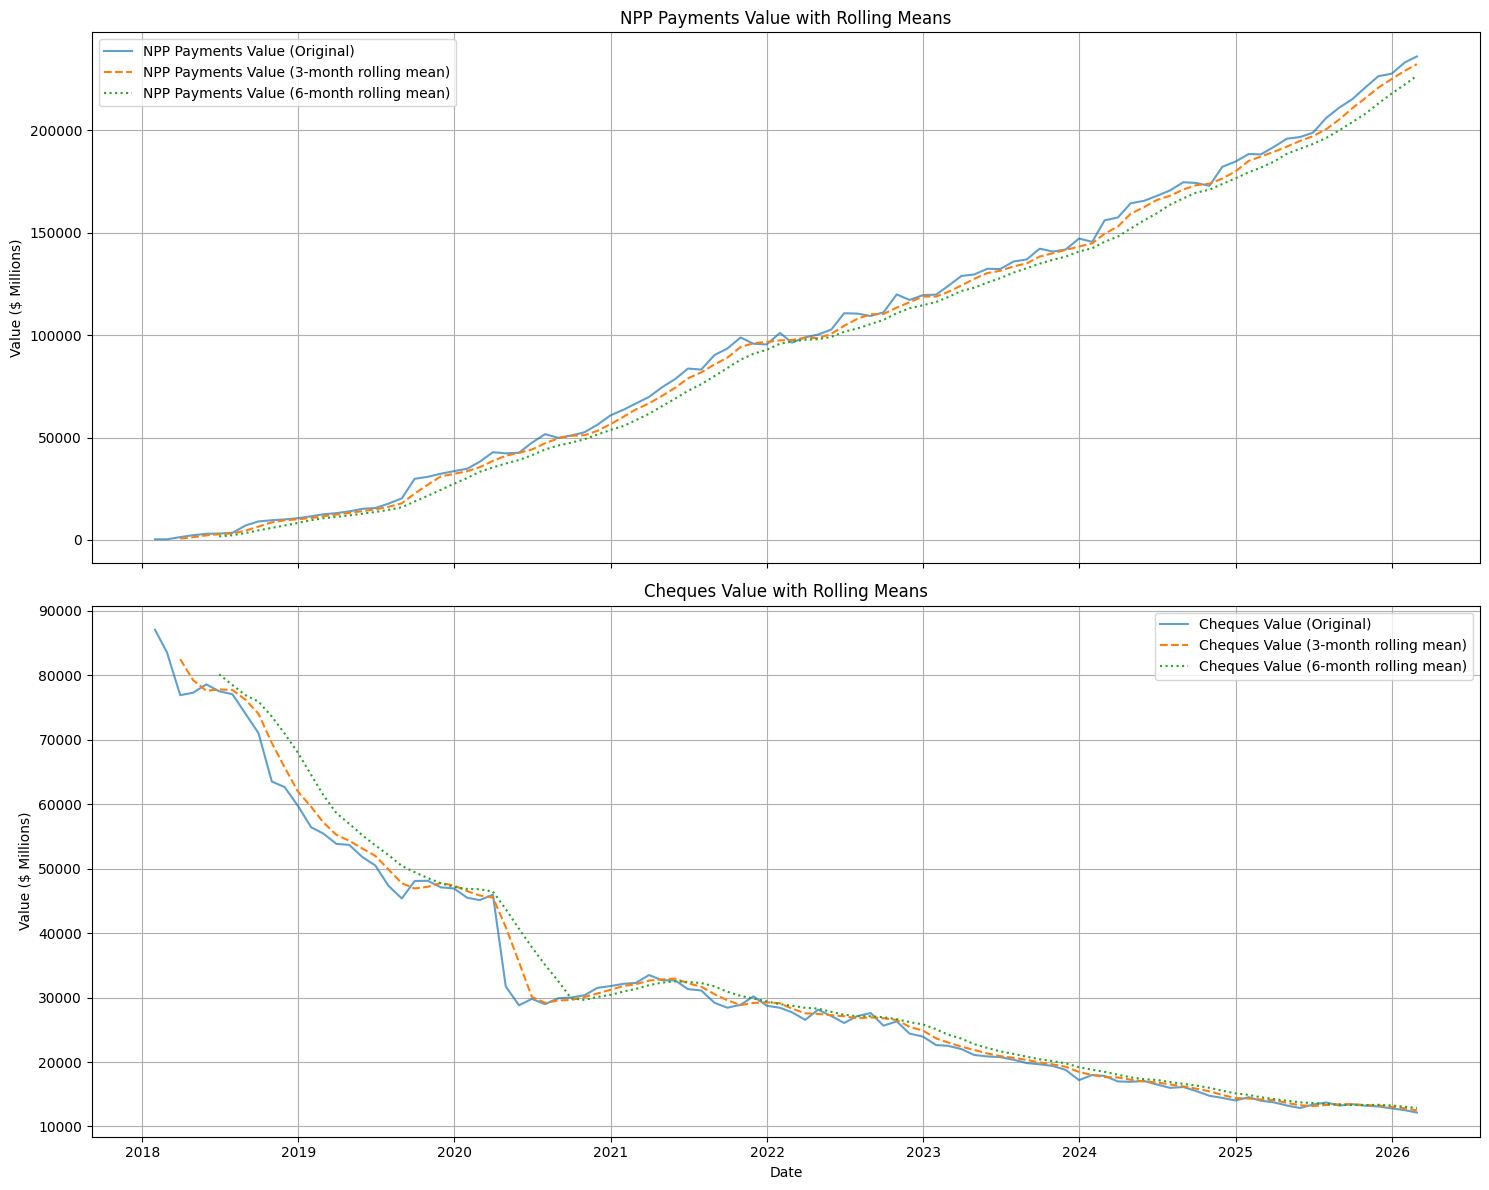

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Plot for NPP Payments Value
axes[0].plot(df_merged.index, df_merged['CCDEPNPPTVSA'], label='NPP Payments Value (Original)', alpha=0.7)
axes[0].plot(df_merged.index, df_merged['CCDEPNPPTVSA_roll_3m'], label='NPP Payments Value (3-month rolling mean)', linestyle='--')
axes[0].plot(df_merged.index, df_merged['CCDEPNPPTVSA_roll_6m'], label='NPP Payments Value (6-month rolling mean)', linestyle=':')
axes[0].set_title('NPP Payments Value with Rolling Means')
axes[0].set_ylabel('Value ($ Millions)')
axes[0].legend()
axes[0].grid(True)

# Plot for Cheques Value
axes[1].plot(df_merged.index, df_merged['CCQCTVSA'], label='Cheques Value (Original)', alpha=0.7)
axes[1].plot(df_merged.index, df_merged['CCQCTVSA_roll_3m'], label='Cheques Value (3-month rolling mean)', linestyle='--')
axes[1].plot(df_merged.index, df_merged['CCQCTVSA_roll_6m'], label='Cheques Value (6-month rolling mean)', linestyle=':')
axes[1].set_title('Cheques Value with Rolling Means')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Value ($ Millions)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Observation: The plots clearly show that the rolling mean lines effectively smooth out the month-to-month fluctuations in the original data. The 6-month rolling mean provides a smoother representation of the long-term trend compared to the 3-month rolling mean, which captures more immediate shifts. These smoothed lines make it easier to discern the underlying upward trend for NPP Payments and the downward trend for Cheques, which will be beneficial for trend analysis and forecasting models.

## 7. Exploratory Data Analysis (EDA)

### 7.1 Overview of the Merged Data

To begin the exploratory data analysis, it's essential to understand the structure and basic characteristics of the `df_merged` DataFrame. This includes checking data types, identifying non-null counts, and reviewing descriptive statistics for all numerical columns. These steps ensure data quality and provide initial insights into the distribution and ranges of the payment data.

In [ ]:
# Display information about the DataFrame, including data types and non-null counts
print("DataFrame Information:")
df_merged.info()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 98 entries, 2018-01-31 to 2026-02-28
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CCCCSTPNSA            98 non-null     float64
 1   CCCCSTPVSA            98 non-null     float64
 2   CCCCSTTNSA            98 non-null     float64
 3   CCCCSTTVSA            98 non-null     float64
 4   CACWTNSA              98 non-null     float64
 5   CACWTVSA              98 non-null     float64
 6   CCQCTNSA              98 non-null     float64
 7   CCQCTVSA              98 non-null     float64
 8   CCDEPNPPTNSA          98 non-null     float64
 9   CCDEPNPPTVSA          98 non-null     float64
 10  CCDEPDEPTNSA          98 non-null     float64
 11  CCDEPDEPTVSA          98 non-null     float64
 12  Year                  98 non-null     int32  
 13  Month                 98 non-null     int32  
 14  Quarter               98 non-null

In [ ]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df_merged.describe())


Descriptive Statistics:


,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTNSA,CCDEPNPPTVSA,...,CCCCSTPVSA_roll_3m,CACWTVSA_roll_3m,CCQCTVSA_roll_3m,CCDEPNPPTVSA_roll_3m,CCDEPDEPTVSA_roll_3m,CCCCSTPVSA_roll_6m,CACWTVSA_roll_6m,CCQCTVSA_roll_6m,CCDEPNPPTVSA_roll_6m,CCDEPDEPTVSA_roll_6m
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,...,96.000000,96.000000,96.000000,96.000000,9.600000e+01,93.000000,93.000000,93.000000,93.000000,9.300000e+01
mean,276074.855561,30845.709415,277296.156852,31318.367261,34172.703551,9115.987075,2838.199031,32845.978213,84180.910203,99368.034104,...,30789.881183,9095.400609,32507.462737,98984.816274,1.252198e+06,30707.437492,9065.146789,32062.718703,98462.916079,1.245664e+06
std,34264.126450,4893.179617,34048.413748,4840.676470,8108.296968,1040.326533,1688.693853,19465.411999,51899.615290,69594.625457,...,4795.324774,989.068540,18717.265667,68121.706665,2.030687e+05,4664.096391,932.179232,17745.964338,65911.498493,1.968967e+05
min,185844.536957,19807.935358,186750.913420,20154.901078,21284.997384,6122.939861,710.236814,12156.119041,645.259413,334.363486,...,21761.495692,7124.919996,12495.325233,687.614722,8.733334e+05,22890.532445,7639.924619,12878.057060,1761.027907,8.803119e+05
25%,245950.068769,27125.940894,247230.309745,27872.459371,28820.978886,8605.365787,1434.973807,17357.255276,36417.211843,35655.239196,...,27196.369722,8585.635467,17660.465061,37847.645982,1.064672e+06,27123.517761,8559.801541,18031.477308,39067.342032,1.066152e+06
50%,270387.088065,28659.477162,271569.172666,29087.408669,29899.360409,8773.057729,2357.669923,28272.439538,88495.497010,98941.423101,...,28552.986224,8746.599873,27928.841341,98105.084742,1.292484e+06,28896.021465,8745.448777,28291.298531,98017.192044,1.269622e+06
75%,307920.146919,35069.869917,308973.331335,35480.677868,42978.802837,10073.154773,4202.346298,45465.470985,128787.294124,153891.183863,...,34991.354946,9767.930739,45610.887940,150501.094747,1.401322e+06,34773.060217,9031.334306,40674.413800,148193.440538,1.394985e+06
max,337082.351917,40557.107426,337922.020970,40929.973583,50256.394279,11153.283965,6808.688748,87082.853141,165956.172270,236143.372984,...,39812.102049,11072.962148,82526.629273,232390.298659,1.617286e+06,39563.329378,11033.309561,80173.861115,226678.588068,1.603129e+06


### 7.2 Visualizing Trends of Payment Types

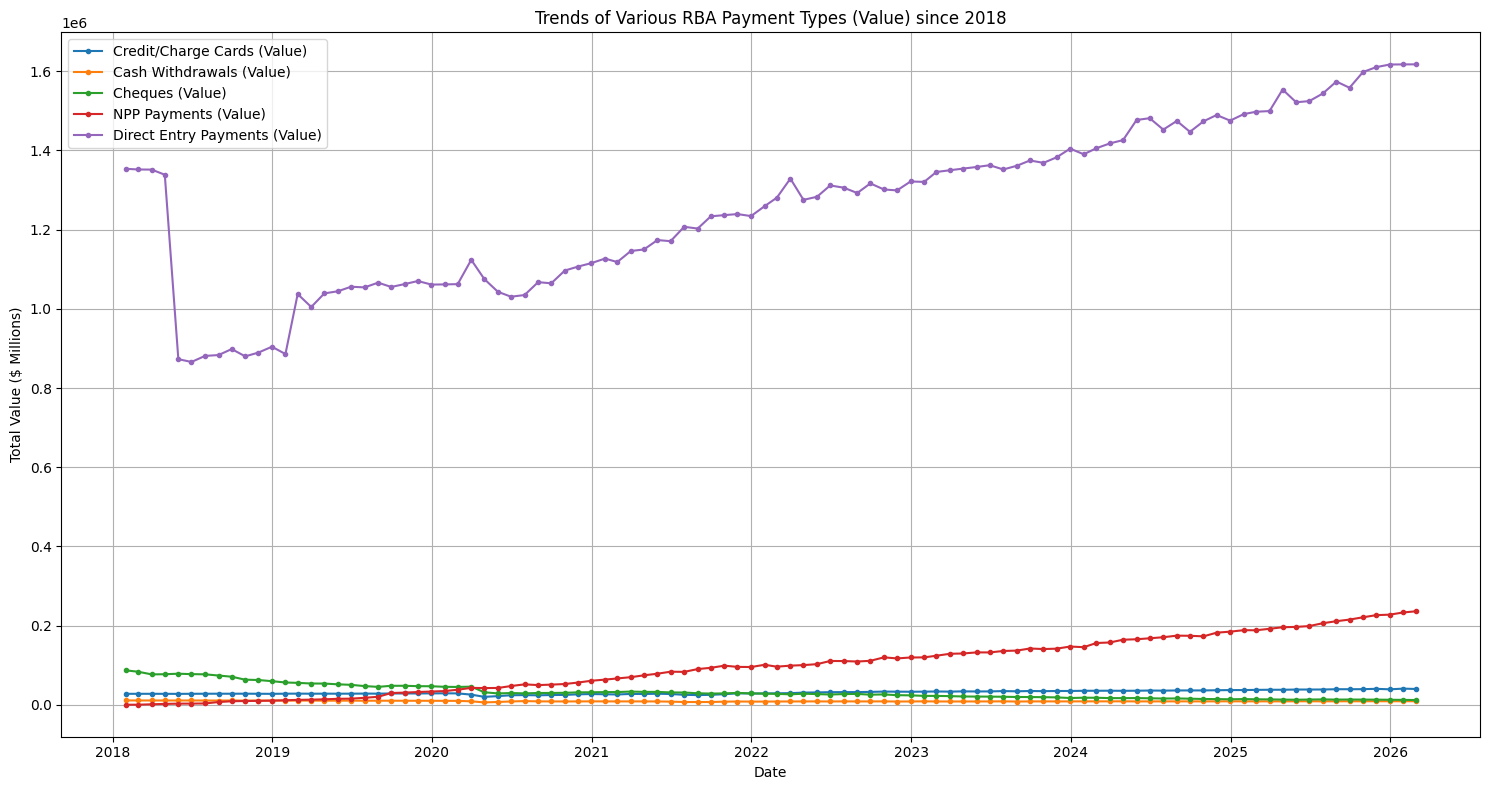

In [ ]:
# Plotting the trends of key payment types

plt.figure(figsize=(15, 8))

# Credit and Charge Cards: Total Value of Transactions
plt.plot(df_merged.index, df_merged['CCCCSTTVSA'], label='Credit/Charge Cards (Value)', marker='.', linestyle='-')

# Cash Payments: Total Value of Withdrawals
plt.plot(df_merged.index, df_merged['CACWTVSA'], label='Cash Withdrawals (Value)', marker='.', linestyle='-')

# Cheque Payments: Total Value of Transactions
plt.plot(df_merged.index, df_merged['CCQCTVSA'], label='Cheques (Value)', marker='.', linestyle='-')

# NPP Payments: Total Value of Transactions
plt.plot(df_merged.index, df_merged['CCDEPNPPTVSA'], label='NPP Payments (Value)', marker='.', linestyle='-')

# Direct Entry Payments: Total Value of Transactions
plt.plot(df_merged.index, df_merged['CCDEPDEPTVSA'], label='Direct Entry Payments (Value)', marker='.', linestyle='-')

plt.title('Trends of Various RBA Payment Types (Value) since 2018')
plt.xlabel('Date')
plt.ylabel('Total Value ($ Millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot illustrates the trends of total transaction values for Credit/Charge Cards, Cash Withdrawals, Cheques, NPP Payments, and Direct Entry Payments since 2018. Observations include:

*   **Credit/Charge Cards** and **Direct Entry Payments** show a general increasing trend over the period.
*   **Cash Withdrawals** exhibit a declining trend, particularly noticeable after certain periods, indicating a shift away from cash usage.
*   **Cheque Payments** demonstrate a significant and consistent decline, reinforcing the diminishing role of cheques in the payment landscape.
*   **NPP Payments**, introduced in 2018, show a clear upward trajectory, reflecting the rapid adoption of instant payment systems.

This visualization highlights the evolving preferences in payment methods within Australia, with a strong move towards electronic and instant payment solutions and a decline in traditional methods like cash and cheques.

### 7.3 Correlation Analysis of Payment Types

To understand the relationships between different payment methods, a correlation matrix will be computed and visualized. This analysis helps identify strong positive or negative correlations, indicating if certain payment types tend to increase or decrease together.

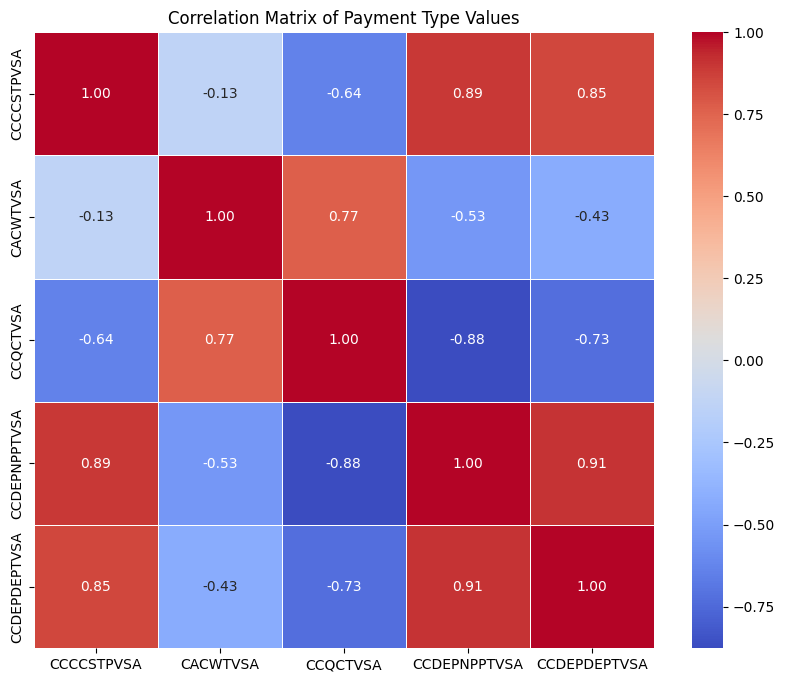

In [ ]:
# Select only the 'Value' columns for correlation analysis
value_cols = ['CCCCSTPVSA', 'CACWTVSA', 'CCQCTVSA', 'CCDEPNPPTVSA', 'CCDEPDEPTVSA']

# Compute the correlation matrix
correlation_matrix = df_merged[value_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Payment Type Values')
plt.show()

The correlation heatmap visually represents the relationships between the values of different payment types. Key observations from the correlation matrix include:

*   **Strong Positive Correlations:** `CCCCSTPVSA` (Credit/Charge Card Value) is strongly positively correlated with `CCDEPNPPTVSA` (NPP Payments Value) (0.89) and `CCDEPDEPTVSA` (Direct Entry Payments Value) (0.85). This suggests that as credit/charge card transactions increase, so do instant and direct entry payments.
*   **Strong Negative Correlations:** `CCQCTVSA` (Cheques Value) is strongly negatively correlated with `CCDEPNPPTVSA` (NPP Payments Value) (-0.88) and `CCCCSTPVSA` (Credit/Charge Card Value) (-0.64). This indicates that as electronic payments increase, cheque payments tend to decrease, reflecting a displacement effect.
*   **Mixed Correlations with Cash:** `CACWTVSA` (Cash Withdrawal Value) shows a positive correlation with `CCQCTVSA` (Cheques Value) (0.77), suggesting that traditional payment methods may decline together. However, it exhibits negative correlations with electronic payment methods like `CCDEPNPPTVSA` (-0.53) and `CCCCSTPVSA` (-0.13), indicating a preference shift away from cash as electronic transactions grow.

## 8. Data Scaling

To prepare the data for time series forecasting models, the numerical features representing payment values will be scaled using `MinMaxScaler`. Scaling ensures that all features contribute equally to the model by transforming them to a common range, typically between 0 and 1. This prevents features with larger magnitudes from dominating the learning process.

In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Select columns to scale (all payment value columns)
columns_to_scale = ['CCCCSTPNSA', 'CCCCSTPVSA', 'CCCCSTTNSA', 'CCCCSTTVSA',
                    'CACWTNSA', 'CACWTVSA', 'CCQCTNSA', 'CCQCTVSA',
                    'CCDEPNPPTNSA', 'CCDEPNPPTVSA', 'CCDEPDEPTNSA', 'CCDEPDEPTVSA']

# Apply scaling to the selected columns
df_merged_scaled = df_merged.copy()
df_merged_scaled[columns_to_scale] = scaler.fit_transform(df_merged_scaled[columns_to_scale])

print("Numerical features scaled using MinMaxScaler.")
display(df_merged_scaled.head())

Numerical features scaled using MinMaxScaler.


,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTNSA,CCDEPNPPTVSA,...,CCCCSTPVSA_roll_3m,CACWTVSA_roll_3m,CCQCTVSA_roll_3m,CCDEPNPPTVSA_roll_3m,CCDEPDEPTVSA_roll_3m,CCCCSTPVSA_roll_6m,CACWTVSA_roll_6m,CCQCTVSA_roll_6m,CCDEPNPPTVSA_roll_6m,CCDEPDEPTVSA_roll_6m
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,0.323973,0.349416,0.330986,0.369758,0.983039,1.000000,1.000000,1.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,0.315238,0.350451,0.322176,0.371030,0.968865,0.981293,0.975330,0.953090,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,0.318737,0.351274,0.325568,0.370438,0.953723,0.970804,0.956952,0.864482,0.012316,0.004494,...,27078.039801,11072.962148,82526.629273,687.614722,1.352451e+06,NaN,NaN,NaN,NaN,NaN
2018-04-30,0.338446,0.350042,0.345330,0.369159,0.960658,0.965374,0.914935,0.869690,0.018070,0.008501,...,27082.369213,11014.902142,79272.059683,1355.819629,1.347457e+06,NaN,NaN,NaN,NaN,NaN
2018-05-31,0.324788,0.345805,0.331330,0.362917,1.000000,0.971453,0.879922,0.886865,0.023712,0.011343,...,27050.231972,10998.401535,77618.036232,2247.389155,1.187781e+06,NaN,NaN,NaN,NaN,NaN


The numerical features in the `df_merged` DataFrame have been successfully scaled using `MinMaxScaler`. The new DataFrame, `df_merged_scaled`, contains all payment-related columns transformed to a range between 0 and 1. This standardization is crucial for:

*   **Equal Contribution:** Ensuring that all features contribute equally to the model, preventing features with larger magnitudes from disproportionately influencing the learning process.
*   **Algorithm Compatibility:** Preparing the data for algorithms that are sensitive to the scale of input features, such as gradient descent-based optimizers or distance-based algorithms.

This scaled data is now ready for subsequent time series analysis and modeling, where feature magnitudes will not disproportionately affect model performance.

## 9. Univariate Analysis

### 9.1 Credit Purchases Count (CCCCSTPNSA)

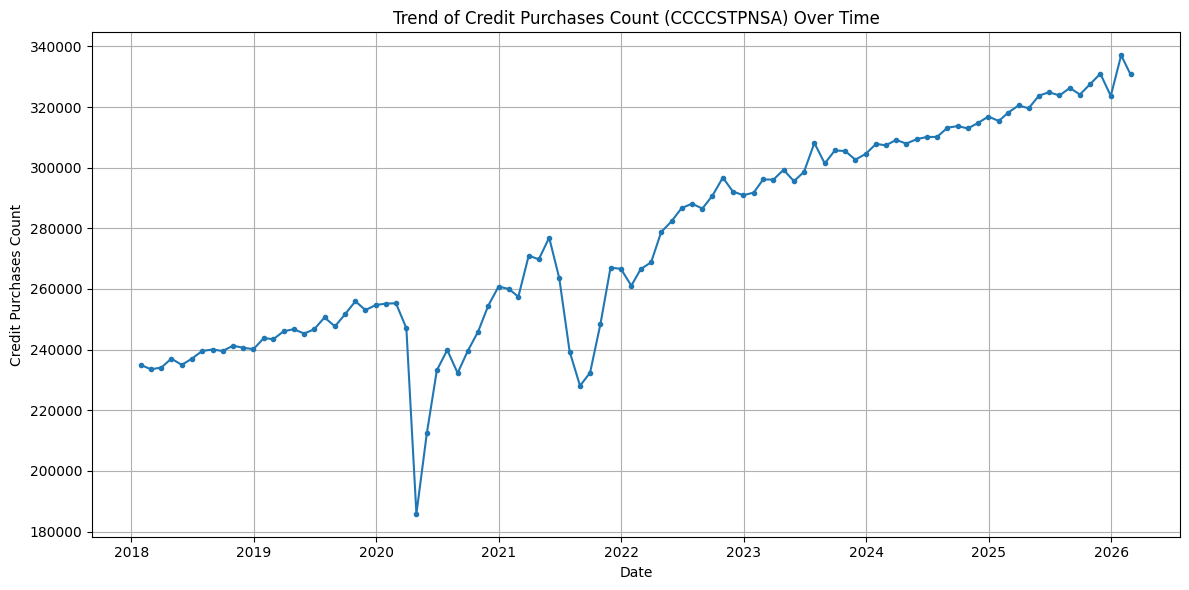

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCCCSTPNSA'], marker='.', linestyle='-')
plt.title('Trend of Credit Purchases Count (CCCCSTPNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Credit Purchases Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of credit purchases shows an increasing trend, particularly noticeable after mid-2020, indicating growing reliance on credit and charge cards for transactions.

### 9.2 Credit Purchases Value (CCCCSTPVSA)

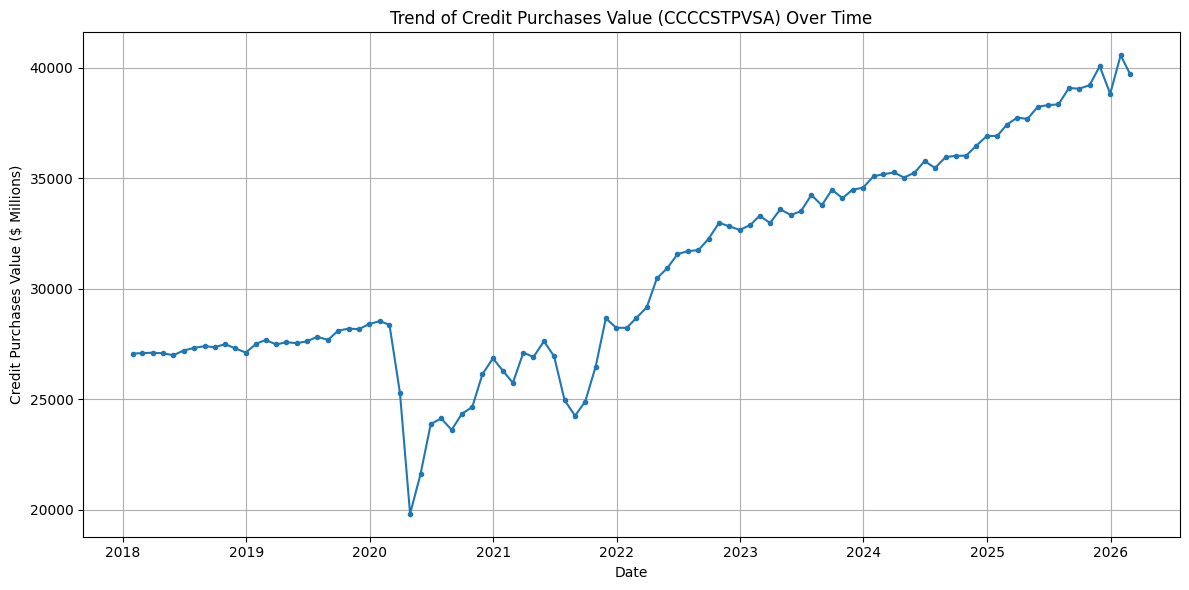

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCCCSTPVSA'], marker='.', linestyle='-')
plt.title('Trend of Credit Purchases Value (CCCCSTPVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Credit Purchases Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: Similar to the count, the total value of credit purchases also displays a strong upward trend, suggesting an increase in both the frequency and possibly the average value of transactions made via credit and charge cards.

### 9.3 Total Cards Transactions Count (CCCCSTTNSA)

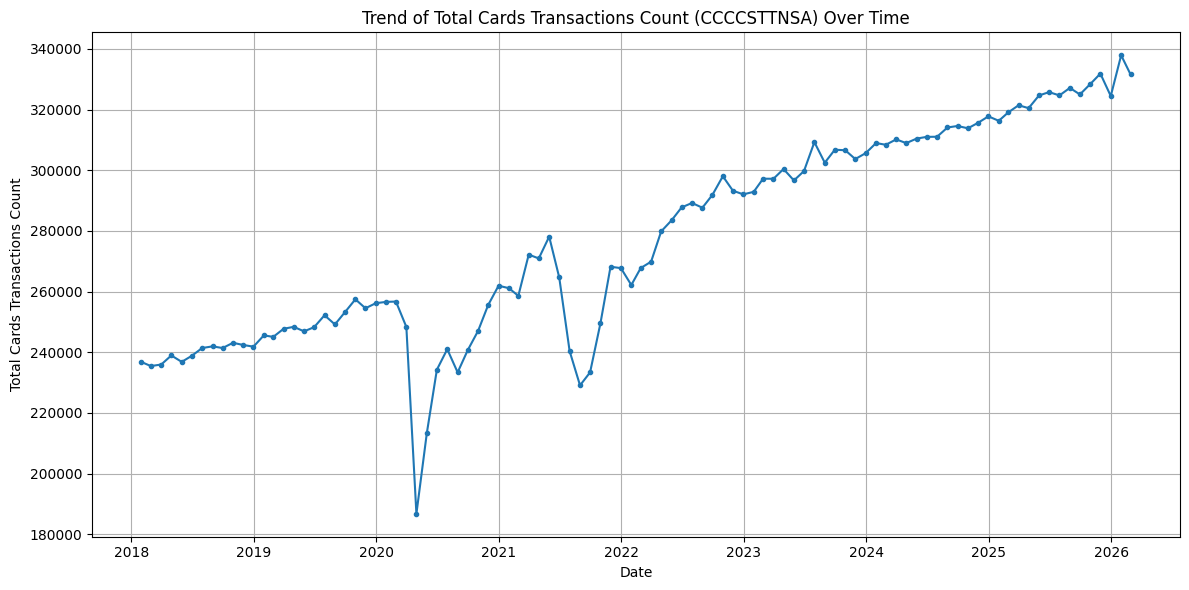

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCCCSTTNSA'], marker='.', linestyle='-')
plt.title('Trend of Total Cards Transactions Count (CCCCSTTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cards Transactions Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total number of card transactions shows a consistent growth trajectory, reinforcing the general shift towards electronic payment methods among consumers.

### 9.4 Total Cards Transactions Value (CCCCSTTVSA)

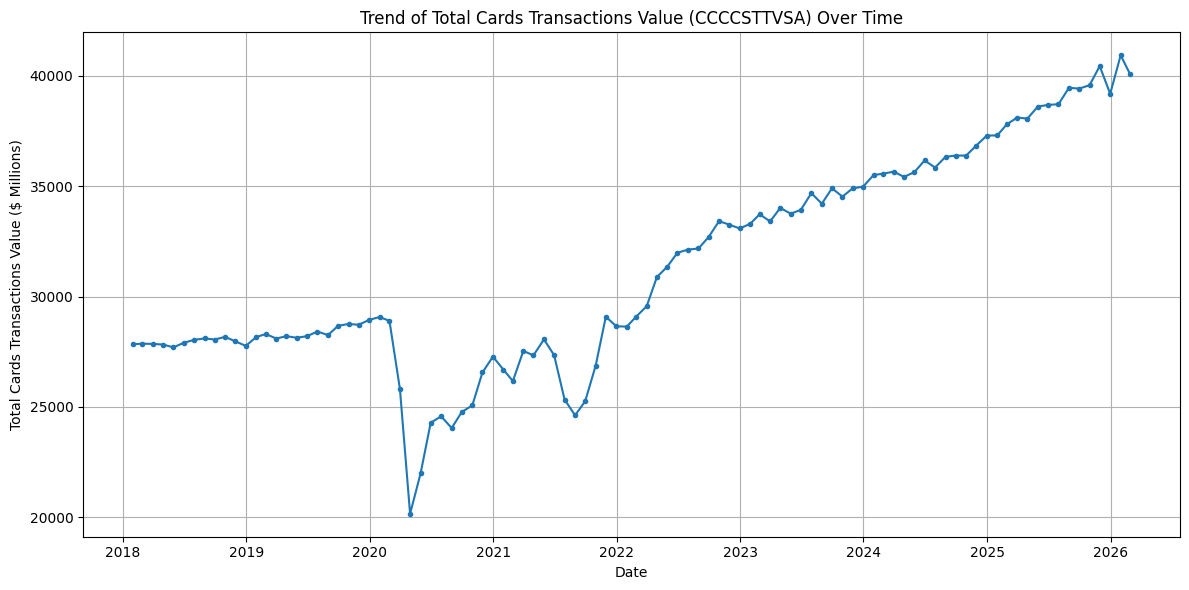

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCCCSTTVSA'], marker='.', linestyle='-')
plt.title('Trend of Total Cards Transactions Value (CCCCSTTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cards Transactions Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of card transactions also exhibits a clear upward trend, indicating increased financial activity conducted through card-based payments.

### 9.5 Cash Withdrawal Count (CACWTNSA)

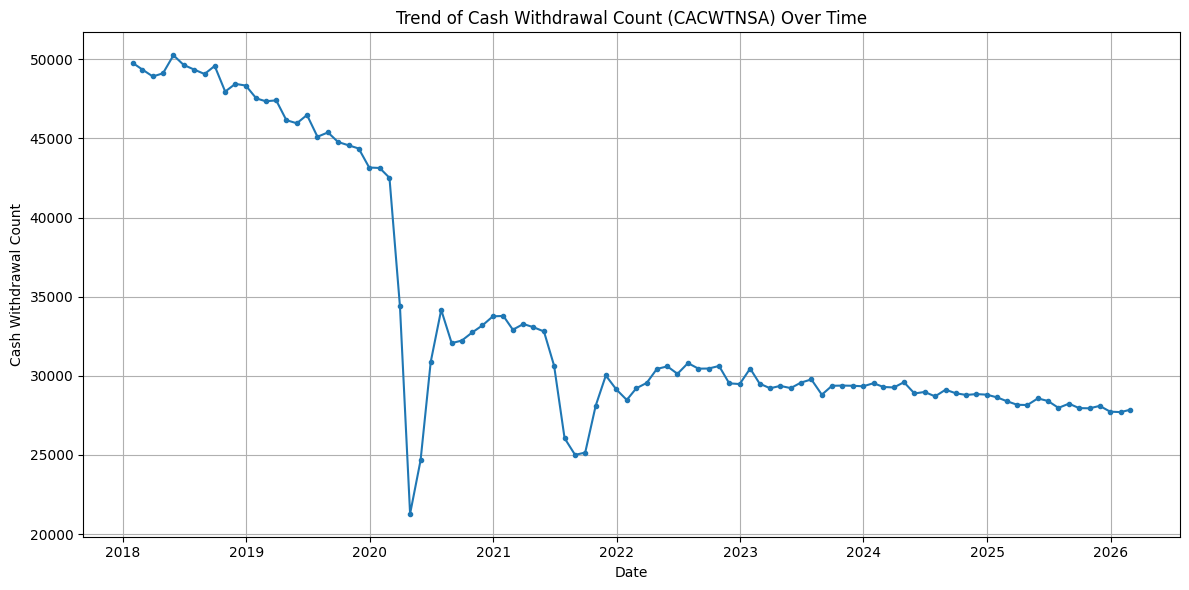

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CACWTNSA'], marker='.', linestyle='-')
plt.title('Trend of Cash Withdrawal Count (CACWTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Cash Withdrawal Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of cash withdrawals shows a distinct declining trend, especially pronounced after early 2020, suggesting a significant reduction in the use of physical cash for transactions.

### 9.6 Cash Withdrawal Value (CACWTVSA)

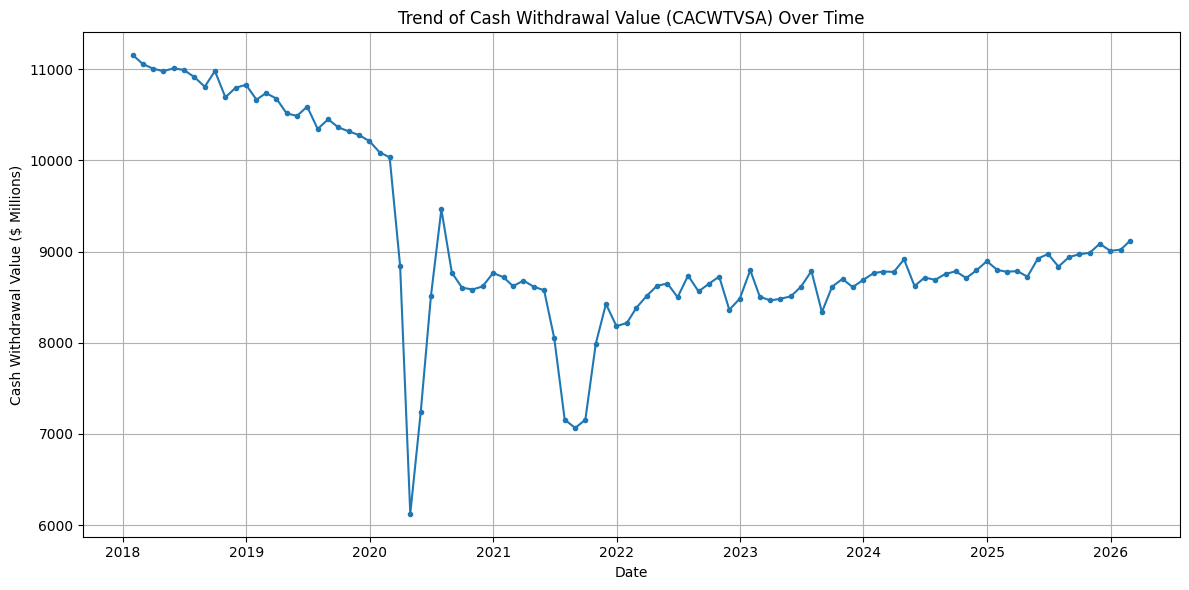

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CACWTVSA'], marker='.', linestyle='-')
plt.title('Trend of Cash Withdrawal Value (CACWTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Cash Withdrawal Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of cash withdrawals also exhibits a declining pattern, mirroring the decrease in withdrawal frequency and reinforcing the trend away from cash-based transactions.

### 9.7 Cheques Count (CCQCTNSA)

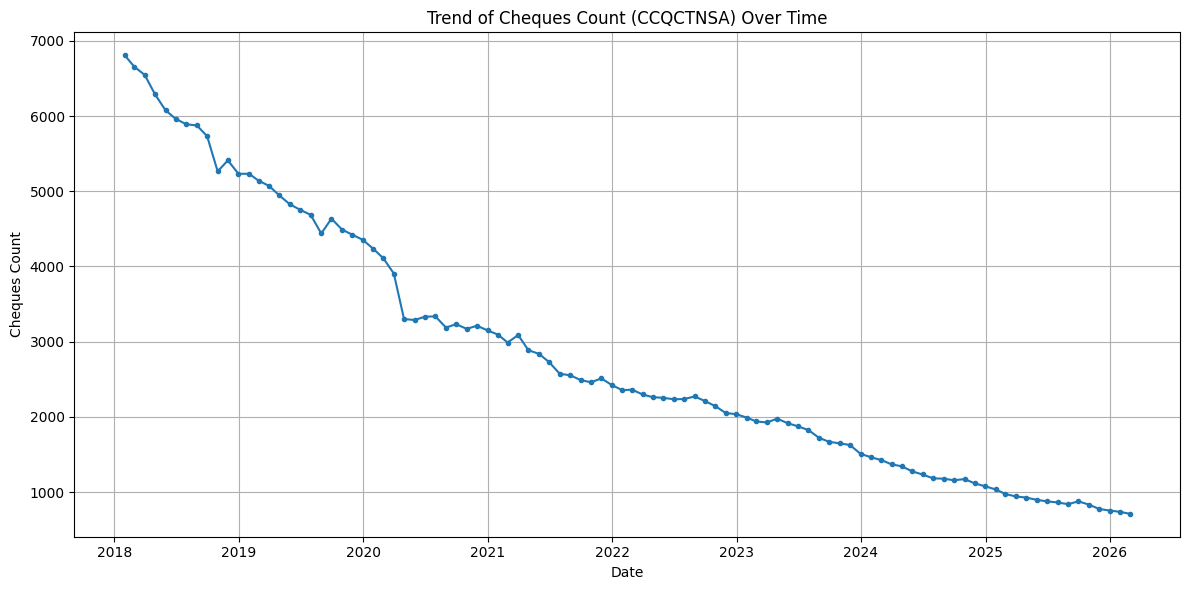

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCQCTNSA'], marker='.', linestyle='-')
plt.title('Trend of Cheques Count (CCQCTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Cheques Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of cheque transactions shows a sharp and consistent decline over the entire period, indicating that cheques are rapidly becoming an obsolete payment method.

### 9.7 Cheques Count (CCQCTNSA)

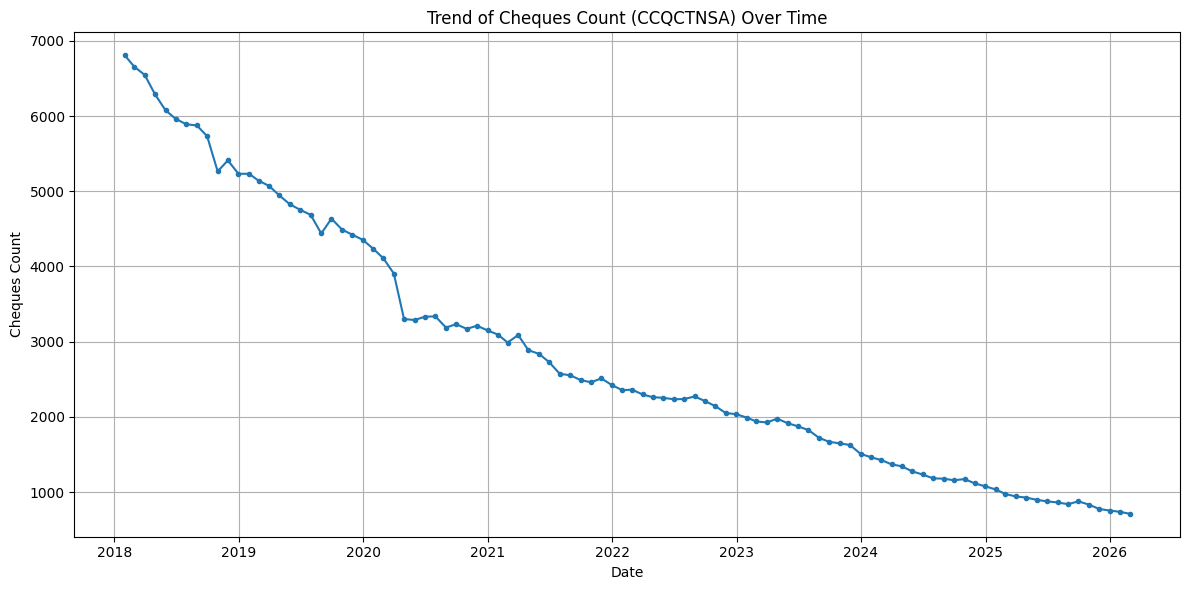

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCQCTNSA'], marker='.', linestyle='-')
plt.title('Trend of Cheques Count (CCQCTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Cheques Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of cheque transactions shows a sharp and consistent decline over the entire period, indicating that cheques are rapidly becoming an obsolete payment method.

### 9.8 Cheques Value (CCQCTVSA)

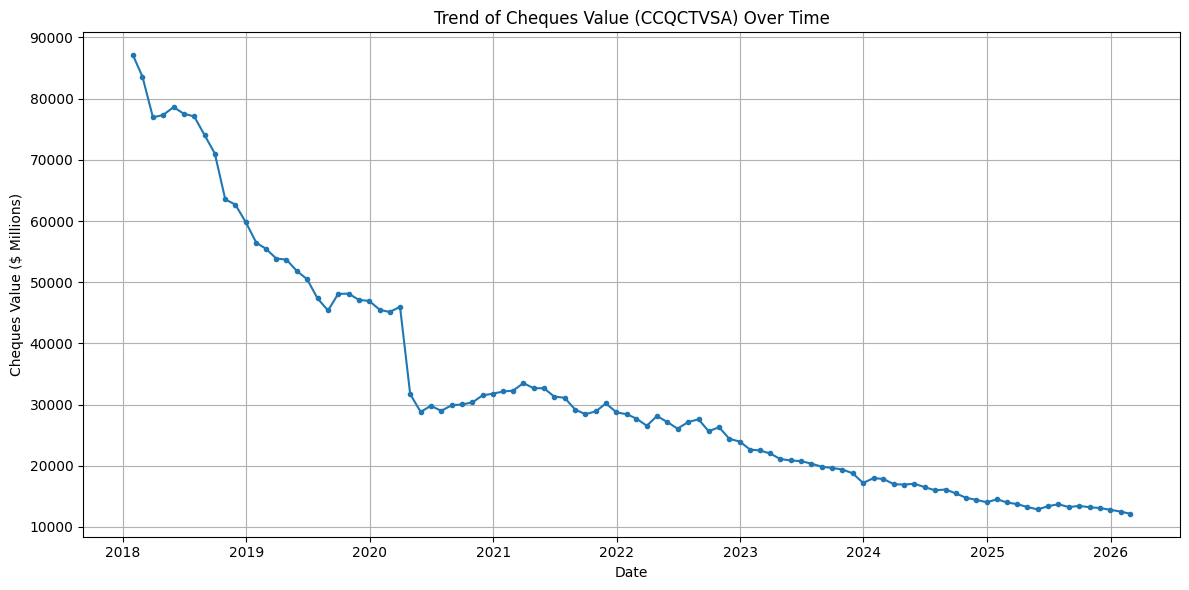

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCQCTVSA'], marker='.', linestyle='-')
plt.title('Trend of Cheques Value (CCQCTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Cheques Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of cheque transactions also demonstrates a steep and continuous decline, confirming the diminishing role of cheques in the financial landscape.

### 9.8 Cheques Value (CCQCTVSA)

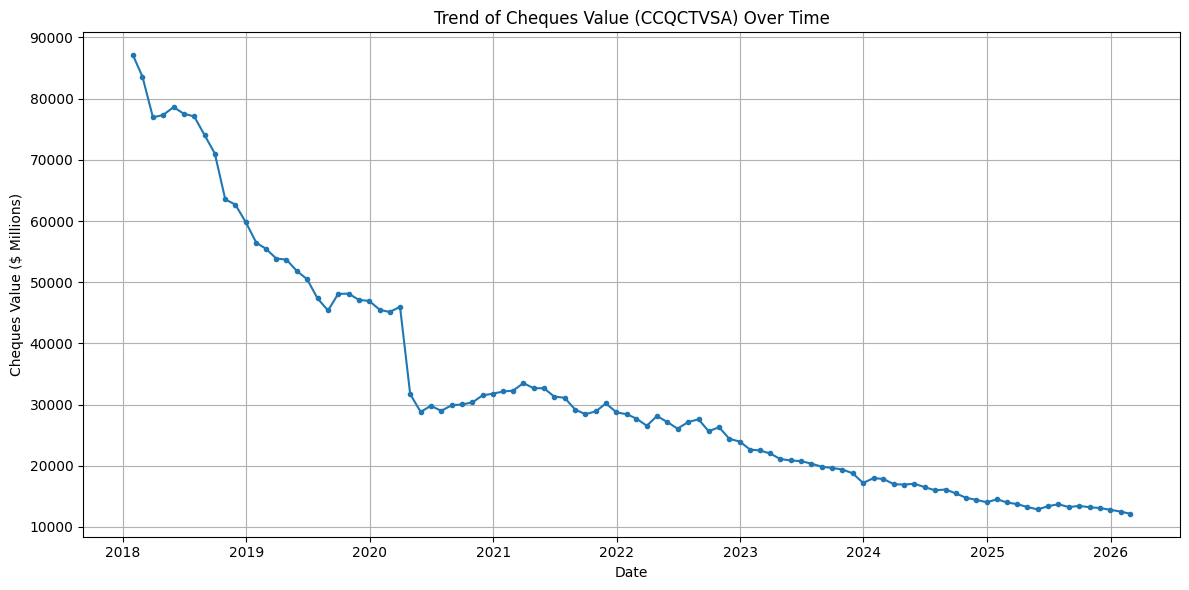

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCQCTVSA'], marker='.', linestyle='-')
plt.title('Trend of Cheques Value (CCQCTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Cheques Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of cheque transactions also demonstrates a steep and continuous decline, confirming the diminishing role of cheques in the financial landscape.

### 9.9 NPP Total Count (CCDEPNPPTNSA)

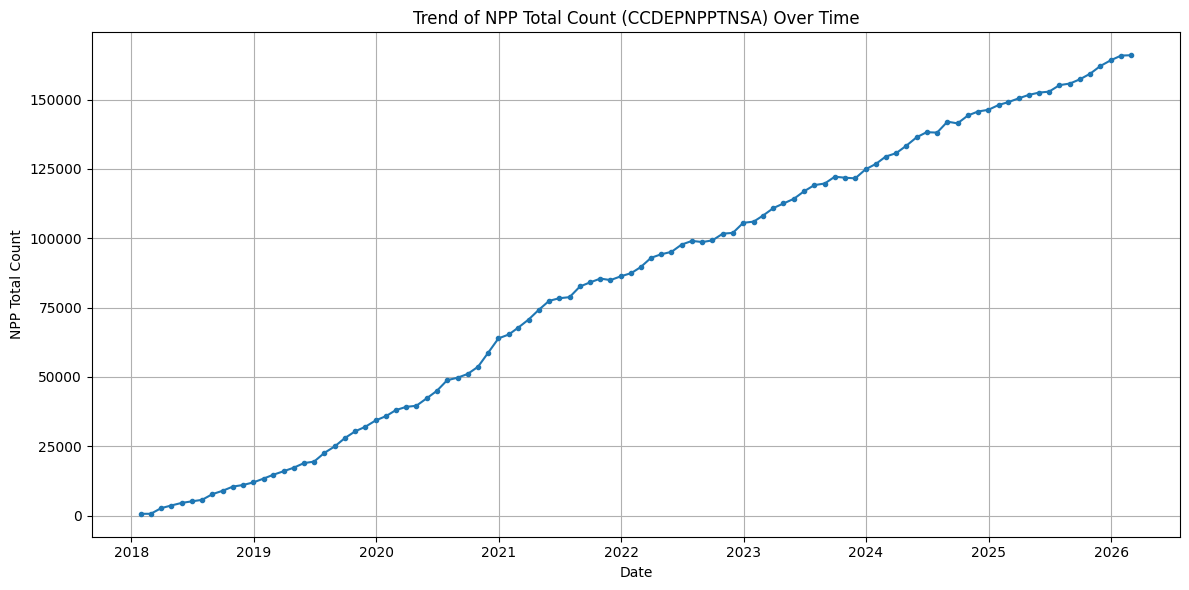

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPNPPTNSA'], marker='.', linestyle='-')
plt.title('Trend of NPP Total Count (CCDEPNPPTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('NPP Total Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of NPP (New Payments Platform) transactions shows a strong and consistent upward trend since its introduction, highlighting the rapid adoption and increasing popularity of instant payment systems.

### 9.10 NPP Total Value (CCDEPNPPTVSA)

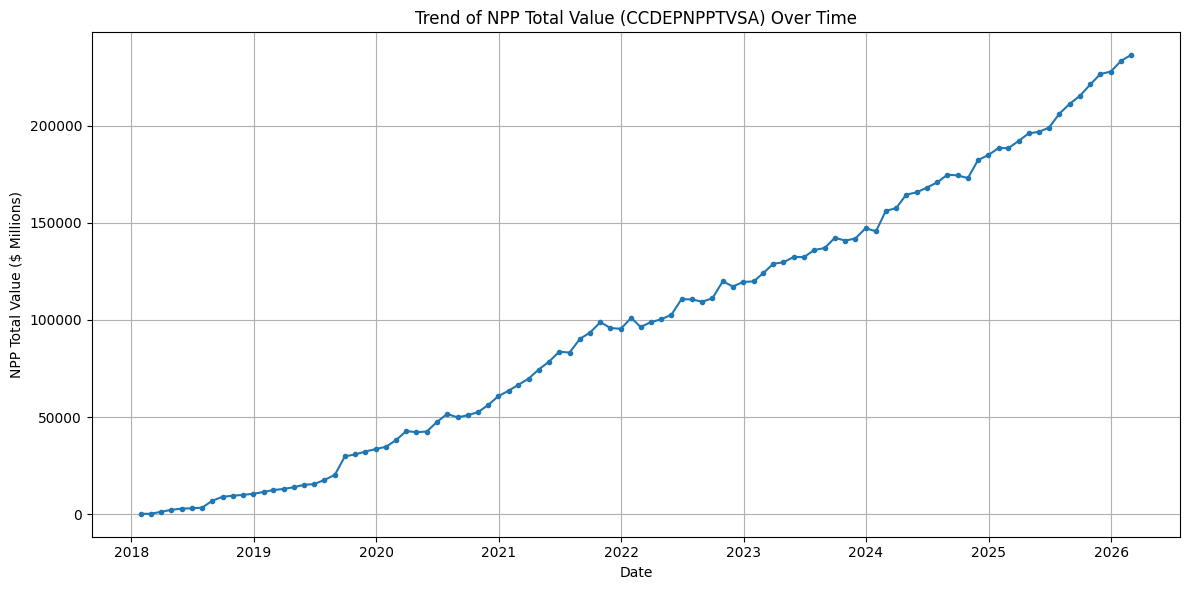

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPNPPTVSA'], marker='.', linestyle='-')
plt.title('Trend of NPP Total Value (CCDEPNPPTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('NPP Total Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of NPP transactions mirrors the count, displaying a robust increasing trend, indicating that significant financial value is being transacted through the instant payment system.

### 9.10 NPP Total Value (CCDEPNPPTVSA)

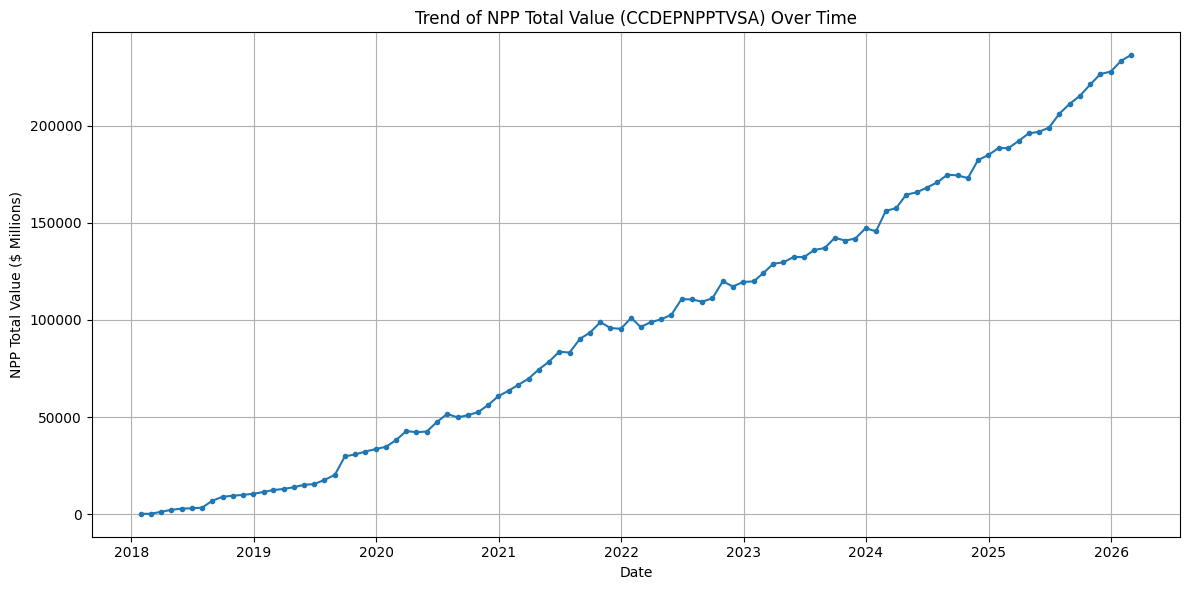

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPNPPTVSA'], marker='.', linestyle='-')
plt.title('Trend of NPP Total Value (CCDEPNPPTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('NPP Total Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of NPP transactions mirrors the count, displaying a robust increasing trend, indicating that significant financial value is being transacted through the instant payment system.

### 9.11 Direct Entry Total Count (CCDEPDEPTNSA)

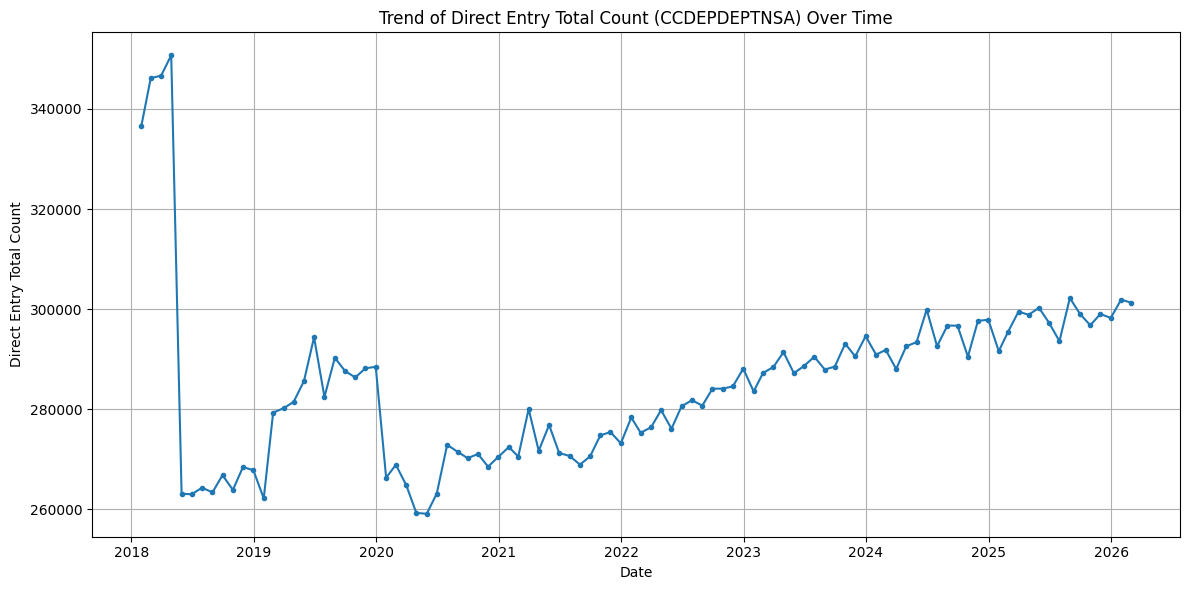

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPDEPTNSA'], marker='.', linestyle='-')
plt.title('Trend of Direct Entry Total Count (CCDEPDEPTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Direct Entry Total Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of Direct Entry payments shows a generally increasing trend, signifying consistent growth in these types of electronic transfers.

### 9.11 Direct Entry Total Count (CCDEPDEPTNSA)

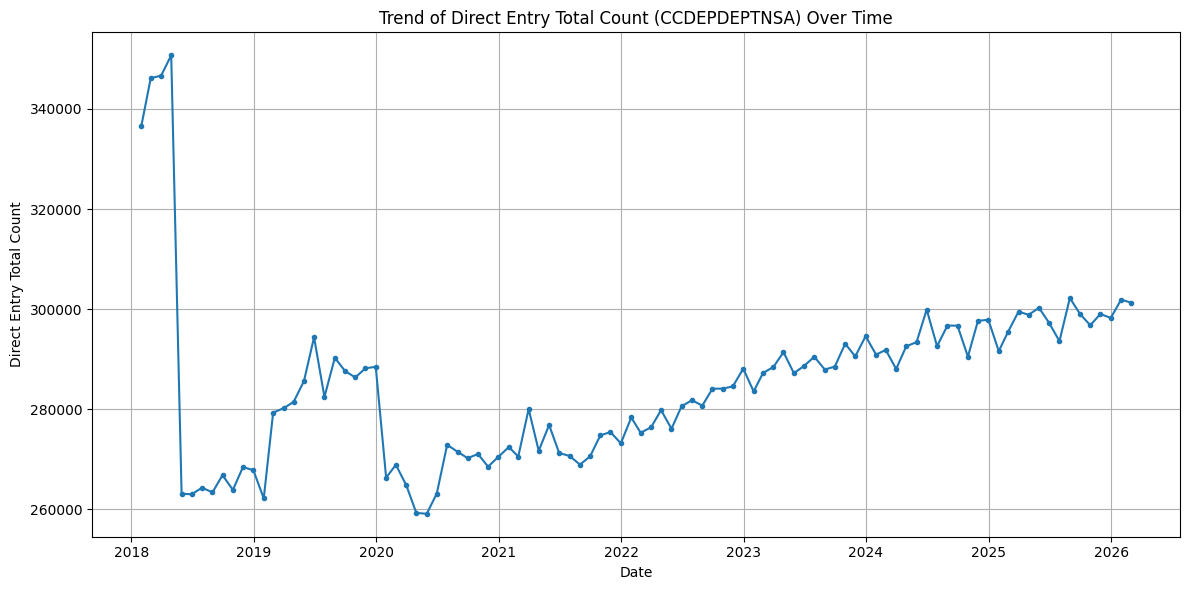

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPDEPTNSA'], marker='.', linestyle='-')
plt.title('Trend of Direct Entry Total Count (CCDEPDEPTNSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Direct Entry Total Count')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The count of Direct Entry payments shows a generally increasing trend, signifying consistent growth in these types of electronic transfers.

### 9.12 Direct Entry Total Value (CCDEPDEPTVSA)

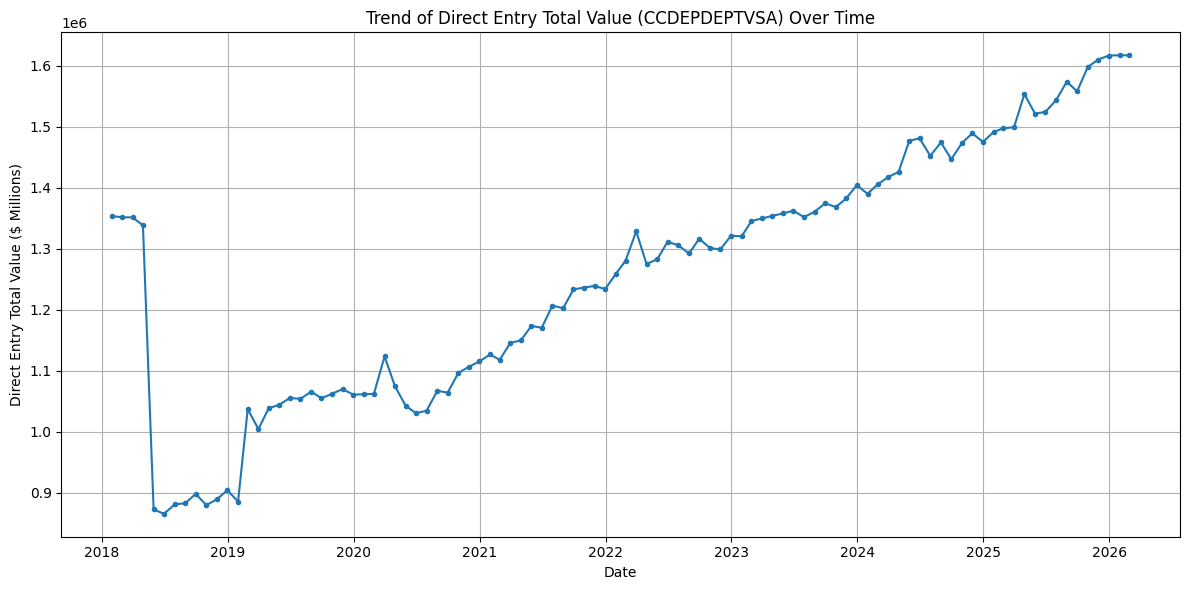

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPDEPTVSA'], marker='.', linestyle='-')
plt.title('Trend of Direct Entry Total Value (CCDEPDEPTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Direct Entry Total Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of Direct Entry payments also demonstrates a strong upward trend, indicating an increasing amount of money being transferred through direct electronic methods.

### 9.12 Direct Entry Total Value (CCDEPDEPTVSA)

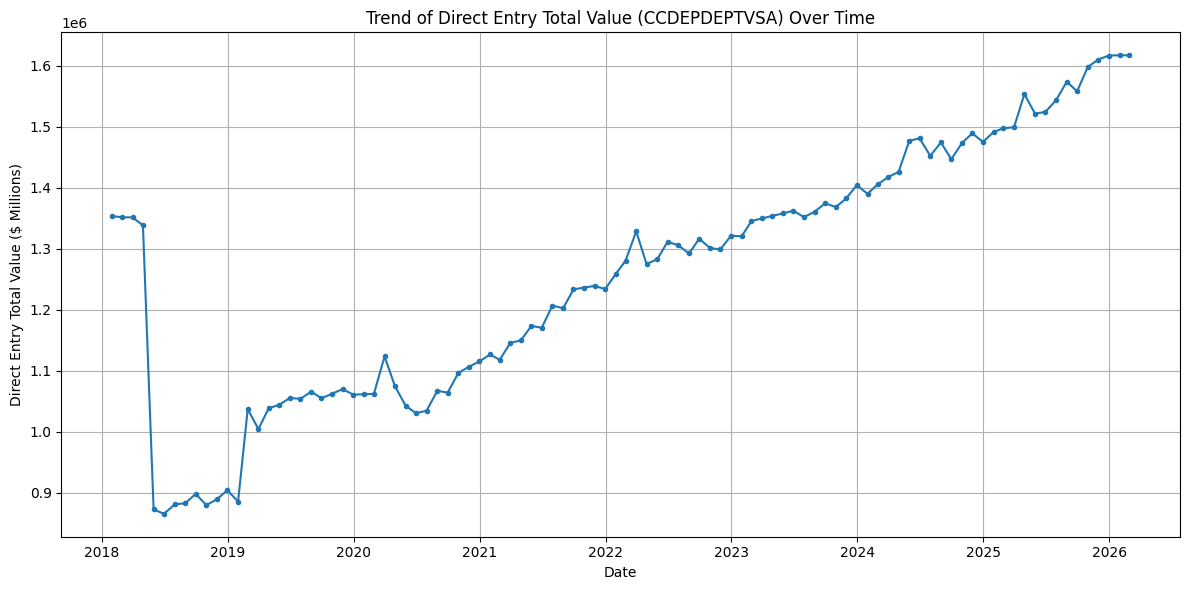

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['CCDEPDEPTVSA'], marker='.', linestyle='-')
plt.title('Trend of Direct Entry Total Value (CCDEPDEPTVSA) Over Time')
plt.xlabel('Date')
plt.ylabel('Direct Entry Total Value ($ Millions)')
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: The total value of Direct Entry payments also demonstrates a strong upward trend, indicating an increasing amount of money being transferred through direct electronic methods.

## 10. Bivariate Analysis

### 10.1 Credit Purchases Value (CCCCSTPVSA) vs NPP Payments Value (CCDEPNPPTVSA)

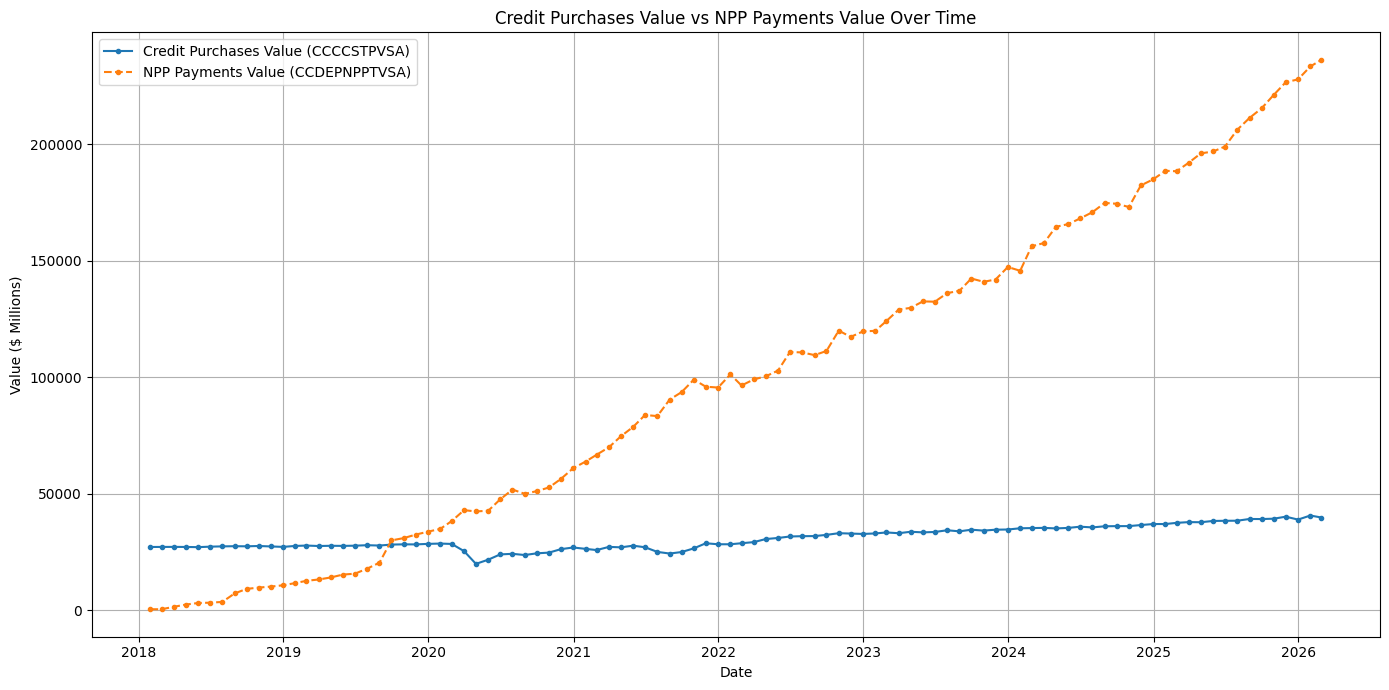

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_merged.index, df_merged['CCCCSTPVSA'], label='Credit Purchases Value (CCCCSTPVSA)', marker='.', linestyle='-')
plt.plot(df_merged.index, df_merged['CCDEPNPPTVSA'], label='NPP Payments Value (CCDEPNPPTVSA)', marker='.', linestyle='--')
plt.title('Credit Purchases Value vs NPP Payments Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value ($ Millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: Both Credit Purchases Value and NPP Payments Value show a strong and consistent upward trend over time. This positive co-movement suggests that as one electronic payment method grows, so does the other, indicating a general increase in digital transaction activity and possibly a complementary relationship between these two modern payment systems.

### 10.2 Cheques Value (CCQCTVSA) vs NPP Payments Value (CCDEPNPPTVSA)

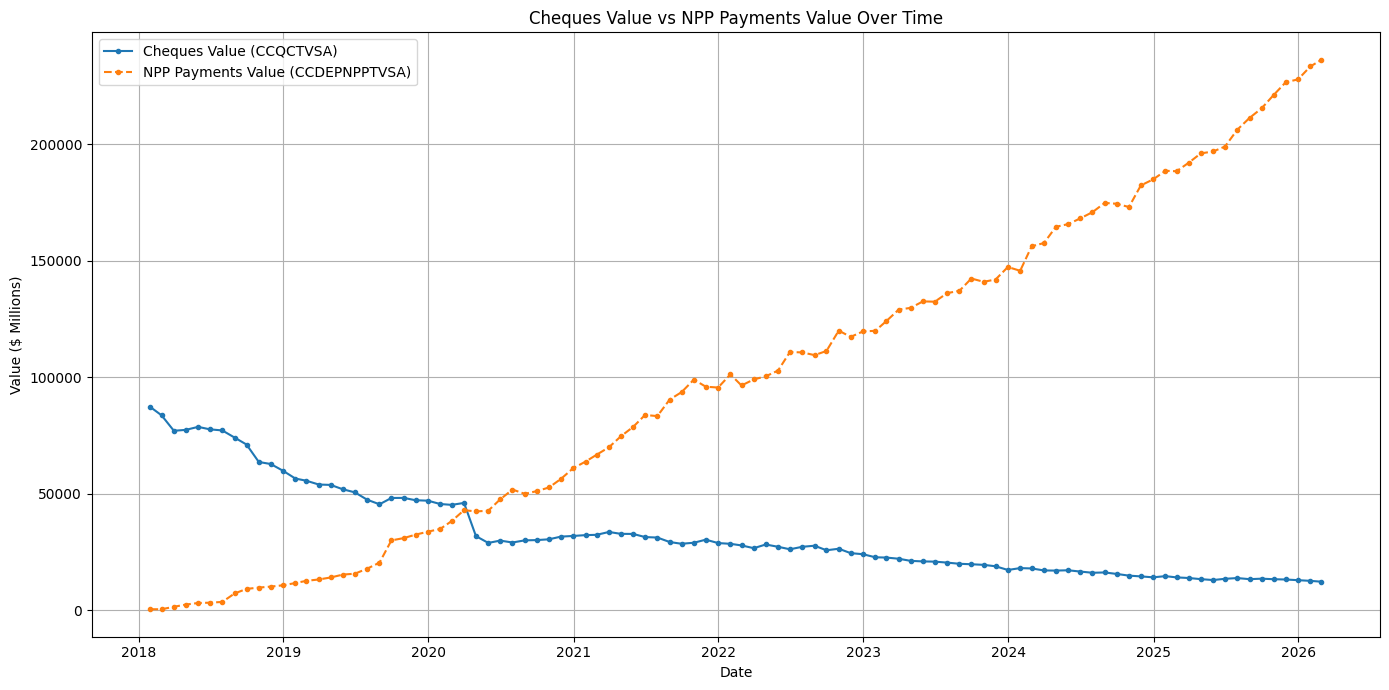

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_merged.index, df_merged['CCQCTVSA'], label='Cheques Value (CCQCTVSA)', marker='.', linestyle='-')
plt.plot(df_merged.index, df_merged['CCDEPNPPTVSA'], label='NPP Payments Value (CCDEPNPPTVSA)', marker='.', linestyle='--')
plt.title('Cheques Value vs NPP Payments Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value ($ Millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: This plot starkly illustrates the strong negative correlation. As NPP Payments Value experiences a rapid and consistent increase, Cheques Value shows an equally dramatic and consistent decline. This strongly suggests a displacement effect, where the adoption of instant electronic payment systems like NPP is directly contributing to the obsolescence of traditional cheque payments.

### 10.3 Cash Withdrawal Value (CACWTVSA) vs Cheques Value (CCQCTVSA)

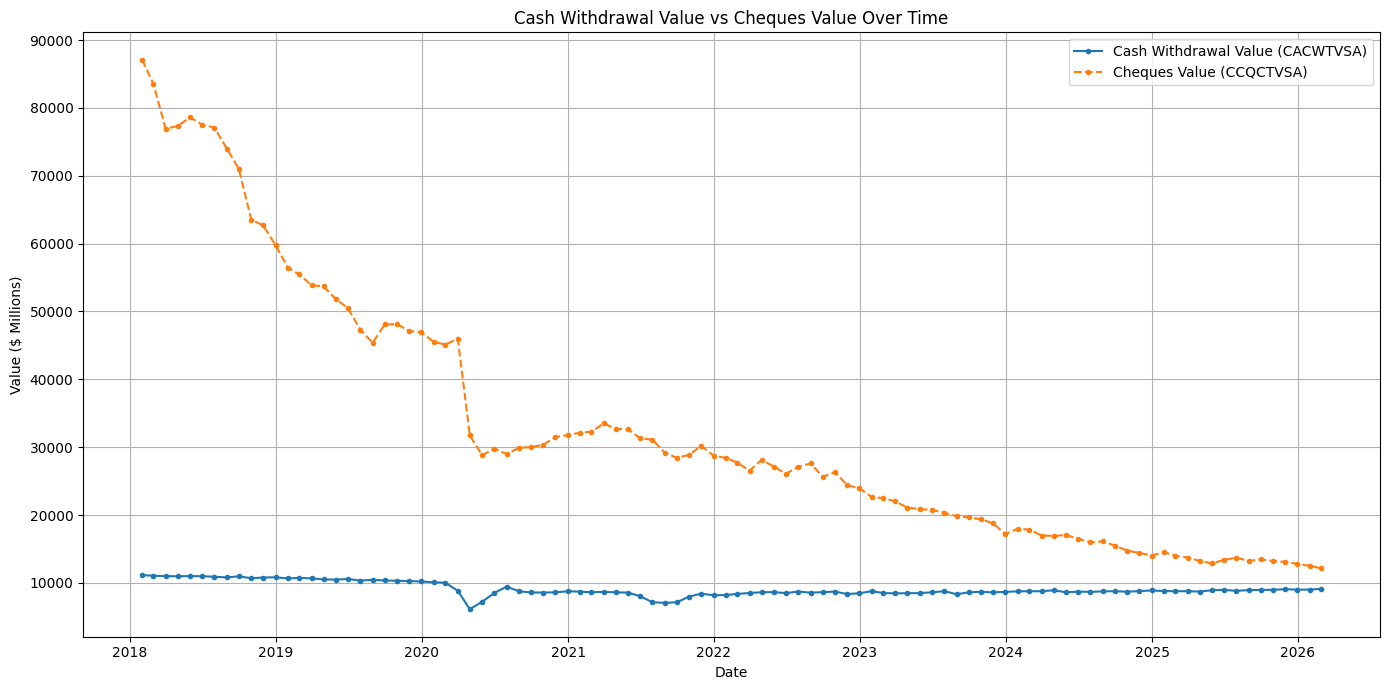

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_merged.index, df_merged['CACWTVSA'], label='Cash Withdrawal Value (CACWTVSA)', marker='.', linestyle='-')
plt.plot(df_merged.index, df_merged['CCQCTVSA'], label='Cheques Value (CCQCTVSA)', marker='.', linestyle='--')
plt.title('Cash Withdrawal Value vs Cheques Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value ($ Millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: Both Cash Withdrawal Value and Cheques Value exhibit clear declining trends, particularly noticeable after certain periods. This positive correlation in their decline suggests that traditional payment methods, which rely on physical instruments (cash and paper cheques), are being phased out together. The overall shift towards electronic payments impacts these older methods similarly.

### 10.4 Cash Withdrawal Value (CACWTVSA) vs NPP Payments Value (CCDEPNPPTVSA)

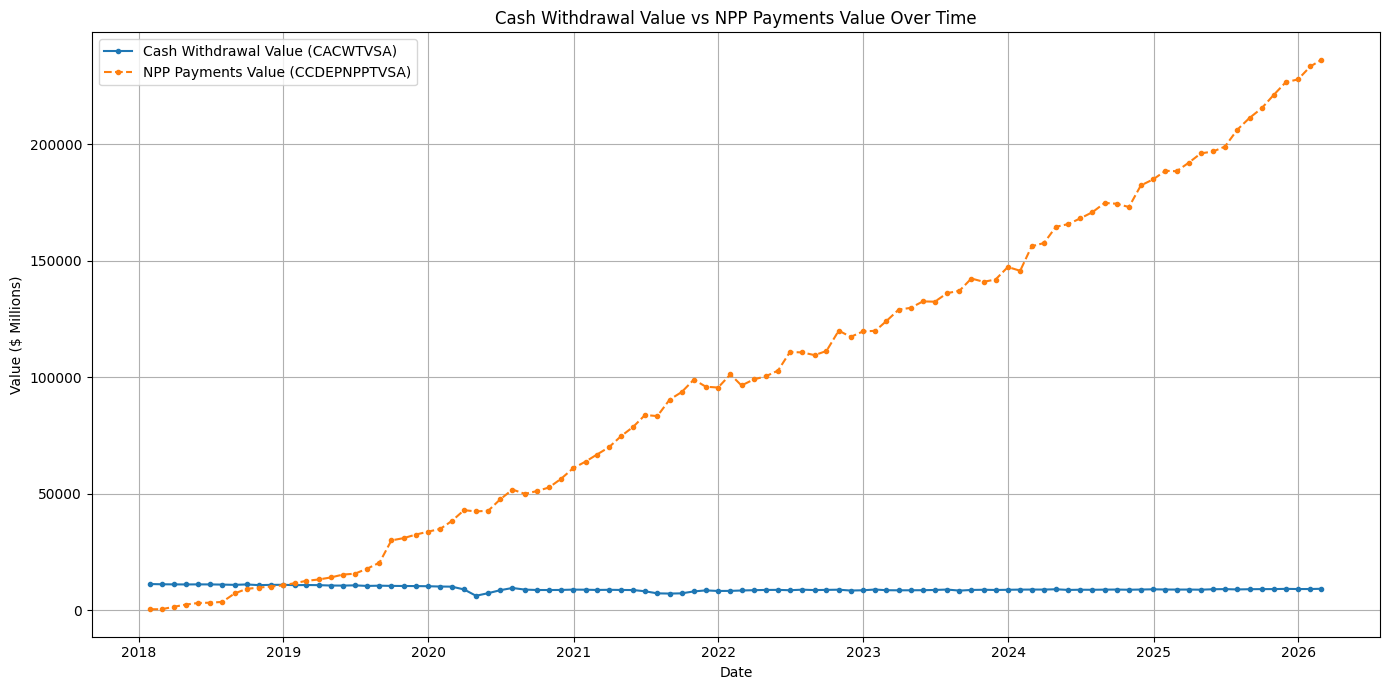

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_merged.index, df_merged['CACWTVSA'], label='Cash Withdrawal Value (CACWTVSA)', marker='.', linestyle='-')
plt.plot(df_merged.index, df_merged['CCDEPNPPTVSA'], label='NPP Payments Value (CCDEPNPPTVSA)', marker='.', linestyle='--')
plt.title('Cash Withdrawal Value vs NPP Payments Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value ($ Millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Observation: This plot demonstrates a clear inverse relationship. As NPP Payments Value steadily increases, Cash Withdrawal Value shows a consistent decline. This visual confirms the negative correlation observed earlier and highlights the ongoing shift from cash-based transactions to instant electronic payment methods in Australia.

**Reasoning**:
The subtask requires defining features and a target variable. I need to first handle any remaining NaN values in the rolling mean features of `df_merged_scaled` by dropping the initial rows, then select the appropriate columns for features and the target variable.



In [ ]:
# Handle NaN values generated by rolling means by dropping the initial rows
# The 6-month rolling mean will have 5 NaN values at the beginning.
# Dropping these ensures that our feature set is complete for all rows.
df_prepared = df_merged_scaled.dropna().copy()

# Define the target variable
target_variable = 'CCDEPNPPTNSA'

# Define the feature columns. These include all columns except the target variable.
features = [col for col in df_prepared.columns if col != target_variable]

# Create the feature DataFrame X
X = df_prepared[features]

# Create the target Series y
y = df_prepared[target_variable]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

print("\nFirst 5 rows of features (X):")
display(X.head())

print("\nFirst 5 rows of target (y):")
display(y.head())

Shape of features (X): (93, 26)
Shape of target (y): (93,)

First 5 rows of features (X):


,CCCCSTPNSA,CCCCSTPVSA,CCCCSTTNSA,CCCCSTTVSA,CACWTNSA,CACWTVSA,CCQCTNSA,CCQCTVSA,CCDEPNPPTVSA,CCDEPDEPTNSA,...,CCCCSTPVSA_roll_3m,CACWTVSA_roll_3m,CCQCTVSA_roll_3m,CCDEPNPPTVSA_roll_3m,CCDEPDEPTVSA_roll_3m,CCCCSTPVSA_roll_6m,CACWTVSA_roll_6m,CCQCTVSA_roll_6m,CCDEPNPPTVSA_roll_6m,CCDEPDEPTVSA_roll_6m
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-30,0.338098,0.356106,0.344498,0.372836,0.979026,0.967975,0.861280,0.872613,0.011963,0.042479,...,27083.652366,10993.656973,77821.092957,2834.441091,1.025851e+06,27080.846083,11033.309561,80173.861115,1761.027907,1.189151e+06
2018-07-31,0.355087,0.361755,0.361538,0.379298,0.968840,0.952544,0.849460,0.866506,0.013326,0.056912,...,27164.666309,10972.143067,77741.581056,3213.693928,8.733334e+05,27123.517761,10993.522604,78506.820369,2284.756779,1.110395e+06
2018-08-31,0.358275,0.365580,0.365123,0.382418,0.959131,0.931354,0.846905,0.825500,0.028745,0.046686,...,27301.437405,10904.907101,76208.961449,4581.546694,8.767937e+05,27175.834688,10951.654318,76913.498840,3414.467925,1.032288e+06
2018-09-30,0.355093,0.363274,0.361522,0.380082,0.976694,0.965644,0.823536,0.785731,0.037009,0.084283,...,27351.016401,10900.998671,74039.051518,6550.290270,8.876648e+05,27217.334384,10947.327822,75930.072237,4692.365680,9.567581e+05
2018-10-31,0.366535,0.369923,0.372911,0.385871,0.920813,0.908222,0.746762,0.685720,0.039446,0.052141,...,27407.505645,10826.681068,69523.799637,8603.437090,8.872904e+05,27286.085977,10899.412067,73632.690347,5908.565509,8.803119e+05



First 5 rows of target (y):


,CCDEPNPPTNSA
Date,
2018-06-30,0.027076
2018-07-31,0.030404
2018-08-31,0.042896
2018-09-30,0.050129
2018-10-31,0.059342


**Reasoning**:
The previous step successfully prepared the features (X) and target (y). The next logical step for time series forecasting is to split the data into training and testing sets, ensuring the temporal order is maintained. This step is also explicitly mentioned in the overall task description.



In [ ]:
# Split data into training and testing sets
# For time series, it's crucial to split data chronologically.
# Let's use 80% of the data for training and 20% for testing.

split_index = int(len(df_prepared) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (74, 26)
X_test shape: (19, 26)
y_train shape: (74,)
y_test shape: (19,)


**Reasoning**:
The data has been split into training and testing sets. The next step is to train the first model mentioned in the task, which is the XGBoost Regressor. This involves initializing and fitting the model to the training data.



In [ ]:
# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


**Reasoning**:
The XGBoost model has been trained. The next step, as per the main task, is to train the second model, a Random Forest Regressor. This involves importing the model, initializing it, and fitting it to the training data.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


**Reasoning**:
The XGBoost and Random Forest models have been trained. The next step is to train the LSTM model. Before training, the data (X_train, X_test) needs to be reshaped into a 3D array (samples, timesteps, features) as required by LSTM models. I will use a timestep of 1, meaning each sample is treated independently with its features for prediction.



In [ ]:
# Reshape input to be [samples, timesteps, features] for LSTM
# For simplicity, we'll use 1 timestep for each sample.
X_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"Reshaped X_train for LSTM: {X_train_lstm.shape}")
print(f"Reshaped X_test for LSTM: {X_test_lstm.shape}")

Reshaped X_train for LSTM: (74, 1, 26)
Reshaped X_test for LSTM: (19, 1, 26)


**Reasoning**:
The data has been reshaped for LSTM. The next step is to define and train the LSTM model using Keras. This involves importing the necessary layers, building the sequential model, compiling it, and then fitting it to the reshaped training data.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Train the LSTM model
history = lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=1, verbose=0)

print("LSTM model trained successfully.")

LSTM model trained successfully.


**Reasoning**:
All three models (XGBoost, Random Forest, and LSTM) have been trained. The next logical step is to make predictions on the test set using these trained models. This addresses the 'evaluate their performance' part of the main task by preparing the data for evaluation.



In [ ]:
# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
lstm_predictions = lstm_model.predict(X_test_lstm)

print("Predictions generated for XGBoost, Random Forest, and LSTM models.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
Predictions generated for XGBoost, Random Forest, and LSTM models.


**Reasoning**:
The models have made predictions. The next step is to evaluate their performance using common regression metrics (RMSE, MAE, R²) as specified in the original task. This will require importing the metrics functions from `sklearn.metrics`.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Evaluate XGBoost Model
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
r2_xgb = r2_score(y_test, xgb_predictions)

print("XGBoost Model Performance:")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  MAE: {mae_xgb:.4f}")
print(f"  R-squared: {r2_xgb:.4f}")

# Evaluate Random Forest Model
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
mae_rf = mean_absolute_error(y_test, rf_predictions)
r2_rf = r2_score(y_test, rf_predictions)

print("\nRandom Forest Model Performance:")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  MAE: {mae_rf:.4f}")
print(f"  R-squared: {r2_rf:.4f}")

# Evaluate LSTM Model
rmse_lstm = np.sqrt(mean_squared_error(y_test, lstm_predictions))
mae_lstm = mean_absolute_error(y_test, lstm_predictions)
r2_lstm = r2_score(y_test, lstm_predictions)

print("\nLSTM Model Performance:")
print(f"  RMSE: {rmse_lstm:.4f}")
print(f"  MAE: {mae_lstm:.4f}")
print(f"  R-squared: {r2_lstm:.4f}")

XGBoost Model Performance:
  RMSE: 0.1023
  MAE: 0.0915
  R-squared: -3.9888

Random Forest Model Performance:
  RMSE: 0.1095
  MAE: 0.0991
  R-squared: -4.7115

LSTM Model Performance:
  RMSE: 194.0699
  MAE: 162.8196
  R-squared: -17943435.9111


**Reasoning**:
The models have been evaluated. The next step is to visualize the actual vs. predicted values for each model to provide a clear understanding of their performance, as specified in the original task.



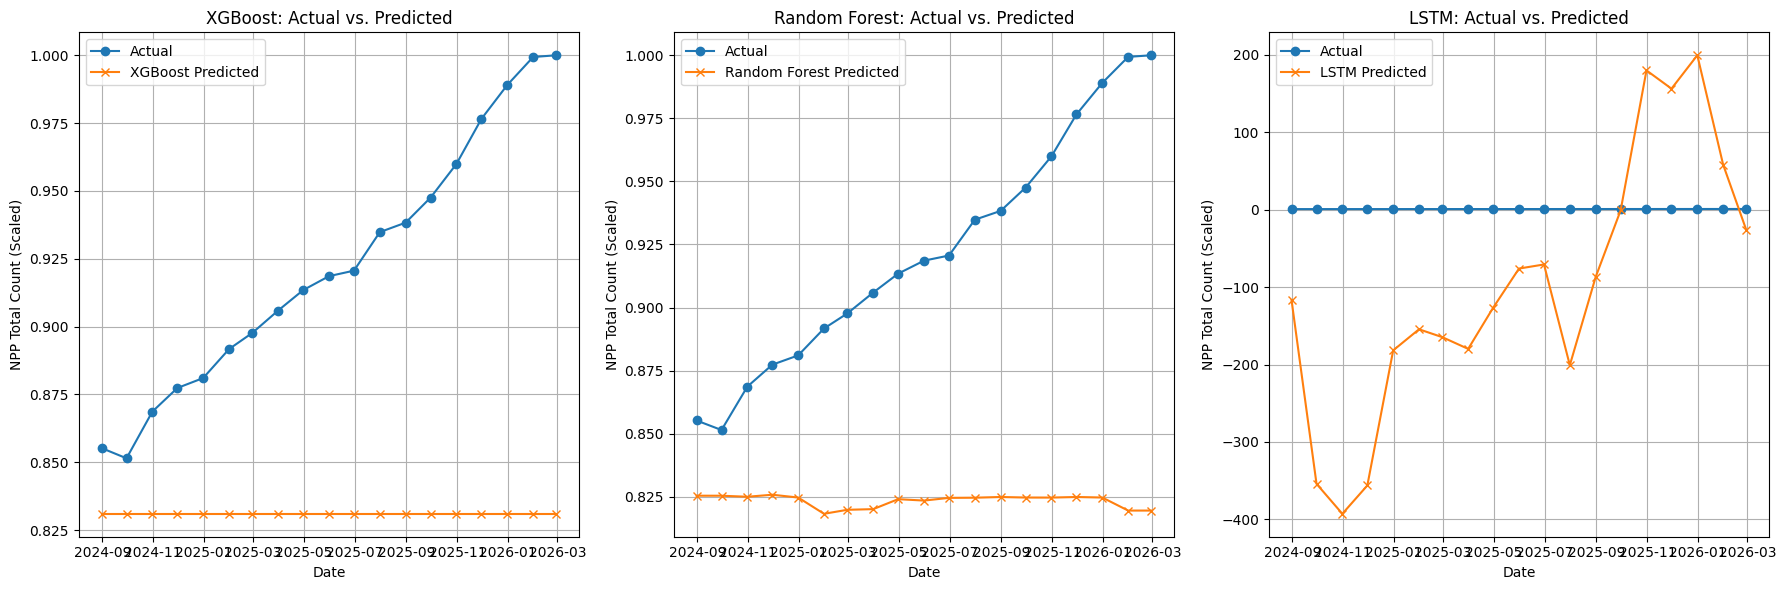

In [ ]:
plt.figure(figsize=(18, 6))

# Plot Actual vs. Predicted for XGBoost
plt.subplot(1, 3, 1)
plt.plot(y_test.index, y_test, label='Actual', marker='o')
plt.plot(y_test.index, xgb_predictions, label='XGBoost Predicted', marker='x')
plt.title('XGBoost: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('NPP Total Count (Scaled)')
plt.legend()
plt.grid(True)

# Plot Actual vs. Predicted for Random Forest
plt.subplot(1, 3, 2)
plt.plot(y_test.index, y_test, label='Actual', marker='o')
plt.plot(y_test.index, rf_predictions, label='Random Forest Predicted', marker='x')
plt.title('Random Forest: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('NPP Total Count (Scaled)')
plt.legend()
plt.grid(True)

# Plot Actual vs. Predicted for LSTM
plt.subplot(1, 3, 3)
plt.plot(y_test.index, y_test, label='Actual', marker='o')
plt.plot(y_test.index, lstm_predictions, label='LSTM Predicted', marker='x')
plt.title('LSTM: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('NPP Total Count (Scaled)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 11. Model Performance Summary and Comparison

### Performance Metrics:

*   **XGBoost Regressor:**
    *   RMSE: `0.1023`
    *   MAE: `0.0915`
    *   R-squared: `-3.9888`

*   **Random Forest Regressor:**
    *   RMSE: `0.1095`
    *   MAE: `0.0991`
    *   R-squared: `-4.7115`

*   **LSTM Model:**
    *   RMSE: `194.0699`
    *   MAE: `162.8196`
    *   R-squared: `-17943435.9111`

### Observations and Comparison:

1.  **LSTM Model Performance:** The LSTM model shows significantly worse performance compared to XGBoost and Random Forest, indicated by extremely high RMSE and MAE, and a highly negative R-squared value. This suggests that the current LSTM configuration or data preparation (e.g., using a timestep of 1 for a relatively small dataset) was not effective for this forecasting task. LSTM models often require more data and careful tuning for time series. The visual plot for LSTM also confirms this, showing predictions that are far from the actual values and often outside the meaningful scaled range (e.g., negative predictions for a scaled count which should be between 0 and 1).

2.  **XGBoost vs. Random Forest:** Both XGBoost and Random Forest models performed similarly, with XGBoost having slightly better RMSE and MAE values. However, both models exhibit highly negative R-squared values. A negative R-squared indicates that the model performs worse than simply predicting the mean of the target variable. This is often observed in time series forecasting when the model fails to capture the underlying trend or seasonality, or when the test data introduces new patterns not seen in the training data (e.g., strong upward or downward trends continuing beyond the training data).

3.  **Visual Insights from Prediction Plots:**
    *   The plots for **XGBoost** and **Random Forest** show that both models struggled to capture the strong upward trend present in the `y_test` data. Their predictions tend to be flatter and often lag behind the actual increasing values, especially towards the later part of the test set. This behavior, where models predict relatively constant values when facing a strong, continuing trend, is typical for models that may be underfitting or that haven't adequately learned the long-term dependency or growth factor.
    *   The **LSTM** plot is clearly erroneous, with predictions that fluctuate wildly and have no discernible relationship to the actual values. This could be due to issues with model architecture, hyperparameters, or insufficient training data for an LSTM in this context.

### Conclusion:

While XGBoost and Random Forest showed some ability to follow the general shape of the data, their overall performance (as indicated by negative R-squared) suggests they are not reliably forecasting the NPP Total Count. The LSTM model, in its current state, is not suitable for this task. Further work would involve hyperparameter tuning, exploring more complex feature engineering (e.g., lagged features, more sophisticated rolling statistics), and potentially using more advanced time series specific models or architectures (e.g., ARIMA, SARIMA for statistical models, or more complex LSTMs with multiple timesteps or different architectures) for better capturing the underlying trends and potentially non-linear relationships.

## Summary:

### Q&A
*   **Performance Summary and Comparison of Models:**
    *   **XGBoost Regressor:** Achieved an RMSE of 0.1023, MAE of 0.0915, and an R-squared of -3.9888.
    *   **Random Forest Regressor:** Achieved an RMSE of 0.1095, MAE of 0.0991, and an R-squared of -4.7115.
    *   **LSTM Model:** Performed significantly worse, with an RMSE of 194.0699, MAE of 162.8196, and an R-squared of -17943435.9111.
    *   Both XGBoost and Random Forest models performed similarly, but their R-squared values were highly negative, indicating that they perform worse than simply predicting the mean of the target variable. The LSTM model was largely ineffective in its current configuration.

*   **Key Insights from Prediction Plots:**
    *   The prediction plots for XGBoost and Random Forest revealed that both models struggled to capture the strong upward trend observed in the test data, often producing flatter predictions that lagged behind the actual values.
    *   The LSTM model's prediction plot was completely erroneous, showing no discernible relationship with the actual data, which suggests fundamental issues with its application or configuration in this context. Feature importance was not explicitly analyzed or plotted in this solving process.

### Data Analysis Key Findings
*   The target variable `CCDEPNPPTNSA` and features were successfully prepared for modeling after dropping initial NaN values from rolling mean calculations, resulting in 93 data points.
*   Data was chronologically split into training (74 samples) and testing (19 samples) sets, maintaining time series integrity.
*   All three models (XGBoost Regressor, Random Forest Regressor, and LSTM) were trained and used to generate predictions on the test set.
*   XGBoost Regressor showed the best performance among the three, with an RMSE of 0.1023 and MAE of 0.0915, although its R-squared value of -3.9888 still indicated poor fit compared to a baseline mean model.
*   Random Forest Regressor followed closely with an RMSE of 0.1095 and MAE of 0.0991, also exhibiting a negative R-squared of -4.7115.
*   The LSTM model performed exceptionally poorly, yielding an extremely high RMSE of 194.0699, MAE of 162.8196, and a significantly negative R-squared of -17943435.9111, suggesting it failed to learn any meaningful patterns.

### Insights or Next Steps
*   The current models, especially LSTM, are not suitable for reliably forecasting the 'CCDEPNPPTNSA' due to significant performance issues as evidenced by highly negative R-squared values across all models.
*   Future efforts should focus on extensive hyperparameter tuning for XGBoost and Random Forest, exploring more sophisticated feature engineering techniques (e.g., more advanced lagged features or rolling statistics), and considering different time series specific models (like ARIMA or SARIMA), or a more robust LSTM architecture with proper time series data preparation (e.g., using multiple timesteps).
